# WARNING
fenotag gpio=1st

# START

In [1]:
import pandas as pd
import numpy as np
import os
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
import re
import ast
from itertools import product
from scipy.spatial.distance import cdist # Added for cdist

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, accuracy_score # Added accuracy_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# from keras.models import Sequential
# from keras.layers import Dense, Dropout
# from keras.utils import to_categorical
# from sklearn.metrics import classification_report, accuracy_score

# from keras.models import Sequential, Model
# from keras.layers import Dense, Dropout, Input, Conv1D, MaxPooling1D, Flatten
# from keras.utils import to_categorical, set_random_seed

# from keras.optimizers import Adam
# from keras.callbacks import ModelCheckpoint, EarlyStopping

#
import tensorflow as tf
from keras.utils import set_random_seed, to_categorical
from keras.models import Sequential, Model
from keras.layers import (Dense, Dropout, Input, Conv1D, Conv2D, MaxPooling1D, MaxPooling2D,
                          Flatten, Reshape, LSTM, SpatialDropout2D, BatchNormalization, concatenate)
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l2
from keras.constraints import max_norm
#

import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import json
from json import loads, dumps

from scipy.signal import find_peaks

def get_nearest_antenna(points, antennas):
    # Returns index of nearest antenna for each point
    dists = cdist(points, antennas)
    return np.argmin(dists, axis=1)


In [2]:


import sklearn
sklearn.__version__

'1.6.1'

file.split('__')[-1].rstrip('.csv')

In [3]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


In [4]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Fri Mar 27 13:25:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
os.getcwd()

'/content'

In [7]:
os.listdir()

['.config', 'drive', 'sample_data']

In [8]:
os.listdir('drive')

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']

In [9]:
# os.listdir('drive/MyDrive')

In [10]:
%cd 'drive/MyDrive/RTLS_SF'

/content/drive/MyDrive/RTLS_SF


In [11]:
os.listdir()

['notebook',
 'raw_data',
 'rtls.xlsx',
 'HQ 21Jan.csv',
 '10.160.230.78.csv',
 '10.160.230.84.csv',
 'final_dataset.csv',
 'final_dataset_foam.csv',
 'ds_basic_17Feb26.csv',
 'ds_advanced_17Feb26.csv',
 'ds_basic_18Feb26.csv',
 'ds_advanced_18Feb26.gsheet',
 'ds_9March26.csv',
 'ds_advanced_18Feb26.csv',
 'ds_Tx.csv',
 'ds_Tx_Rx.csv',
 'ds_elemen.csv',
 'Actuals.csv',
 'HQ STAR3K RTLS Layout.pptx']

# RFID data

pathfiles

# PX2025 & HQ

In [ ]:


# Pathfiles_dict = {\

#       # ESISAR PX small room, square2m
#       'ConfID=2025-10-21 14h00__Item=foam__Qtags=10__Carrier=sapiens__Speed=static__Site=esisar__antConf=floor__ antSep=2m__antTilt=0':\
#       {'Reader=SF__Session=S0__Power=30dBm__Q=4':\
#            [ 'id=2025-10-21 16h00'],\
#       },\

#       # ESISAR PX small room, colocated antennas in NSEW
#       # 'ConfID=2025-11-18__Item=foam__Qtags=10__Carrier=sapiens__Speed=static__Site=esisar__antConf=floor__ antSep=0m__antTilt=45':\
#       # {'Reader=SF__Session=S0__Power=30dBm__Q=4':\
#       #      [ 'id=2025-11-18 14h00'],\
#       #  },\

#       # ESISAR PX anechoic chamber, colocated antennas in NSEW
#       #  'ConfID=2025-12-02__Item=foam__Qtags=10__Carrier=sapiens__Speed=static__Site=anechoic_esisar__antConf=floor__ antSep=0m__antTilt=45':\
#       #  {'Reader=SF__Session=S0__Power=30dBm__Q=6':\
#       #       [ 'id=2025-12-02 14h00'],\
#       #  },\

#       # HQ
#       # 'ConfID=2025-12-10__Item=cardboard__Qtags=20__antQ=8__Site=AcceliotIncHQ':\
#       # {'Reader=SF__Session=S?__Power=30dBm__Q=?':\
#       #      [ 'id=2025-12-10'],\
#       # },\
#       #'ConfID=2026-01-21__obj=test__Item=cardboard__Qtags=20__antQ=8__Site=AcceliotIncHQ':\
#       #{'Reader=SF__Session=S1__Power=31.5dBm':\
#       #     [ 'id=2026-01-21 22h'],\
#       # },\
#                  }


# SuitSupply

In [ ]:
#Pathfiles_dict = {\

#       # SS

      # 'ConfID=2026-01-29__site=SuitSupply_Paris__zone=FOH__reader=SF8' :
#       {'pgm=mojixMCON':\
#           ['id=2026-02-01'],\
#       },\
#                   }
# Pathfiles_dict = {\

#       # SS

      #'ConfID=2026-02-19__site=SuitSupply__SF=SF8' :

      # {'pgm=AEP__Q=5-10':\
      #     ['id=2026-02-19 00h15'],\
      # },\

      # 30min run S1Q8
      # {'pgm=AEP__Q=8__session=S1':\
      #     ['id=2026-02-20'],\
      # },\

                 # }


# HQ 1 tower

In [12]:
# id=2026-02-10: no measuring laser tool .... doubt
Pathfiles_dict = {\

      # HQ

      'ConfID=2026-02-03__site=HQ' :
      {'pgm=AEP_OK':\
          ['id=2026-02-04', 'id=2026-02-05', 'id=2026-02-06', 'id=2026-02-10', 'id=2026-02-11', 'id=2026-02-12', 'id=2026-02-13', 'id=2026-02-17'],\
      },\

      # Q
      # {'pgm=AEP__Q=5-10':\
      #     ['id=2026-02-20'],\
      # },\

      # s2q8 basic
      #  {'pgm=basic__session=s1s2__q=8':\
      #     ['id=2026-02-22'],\
      # },\

#     adjSF + 1000 tags, id=2026-02-21 10h00=3min, id=2026-02-21 11h00=30min
      # 'ConfID=2026-02-21__Qtags=1000__adjSF=True__site=HQ' :
      # {'pgm=AEP__session=1__q=8':\
      #     ['id=2026-02-21 11h00'],\
      # },\
                  }

# raw data

HQ: runs (x,y,z0), Actuals (z_rel)

In [13]:
RoundStart = pd.DataFrame()
gpio = pd.DataFrame()
Runs = []
tags = pd.DataFrame()
Actuals = pd.DataFrame()

for Conf in Pathfiles_dict.keys():
  #print(Conf)
  for Reader in Pathfiles_dict[Conf].keys():
    #print(Reader)
    settings_Conf_Reader = Conf + '__' + Reader
    # print(settings_Conf_Reader)
    for runID in Pathfiles_dict[Conf][Reader]:
      #print(runID)
      settings_Conf_Reader_runID = settings_Conf_Reader + '__' + runID

      pathfile = os.path.join ('raw_data', Conf, Reader, runID)
      # print(os.listdir(pathfile))
      for file in os.listdir(pathfile):
        print(file)
        if file.endswith('txt'):
      # print(file)
          settings = settings_Conf_Reader_runID + '__' + file.rstrip('.txt')
          #print(settings)
          settings = [x.split('=') for x in settings.split('__') ]
          #print(settings)
          settings = {key:value for key, value in settings}
      # print(settings)
          filename = os.path.join(pathfile, file)
          errors_json=0
          counter_lines=0
          with open(filename, 'rt') as lines:
            run=0
            tags_run=[]
            RoundStart_run=[]
            gpio_run=[]

            for line in lines:
              if line.startswith('data: '):
                data_str = line.split('data: ')[1]
                try:
                  data_json = json.loads(data_str)
                  if run==0:
                    run=data_json['datestamp']
                    run=pd.to_datetime(run, format='%y/%m/%d %H:%M:%S.%f').round('1s')
                    #print(run)
                    settings['run']=run

                  if data_json['type']=='RoundStart':
                    RoundStart_run.append(data_json)
                  if data_json['type']=='TagReadData':
                    tags_run.append(data_json)
                  if data_json['type']=='SensorData':
                    gpio_run.append(data_json)
                except:
                  errors_json += 1
        # print(tags_run)
            tags_run = pd.DataFrame(tags_run)
            tags_run['run'] = run
        # ConfID = settings['ConfID']
        # tags_run['ConfID'] = ConfID
    #
        # for key, value in settings.items():
        #   tags_run[key] = value

            Runs.append(settings)

            tags = pd.concat([tags, tags_run])
            RoundStart_run = pd.DataFrame(RoundStart_run)
            RoundStart_run['run'] = run
        # RoundStart_run['ConfID'] = ConfID
            RoundStart = pd.concat([RoundStart, RoundStart_run])
            gpio_run = pd.DataFrame(gpio_run)
            gpio_run['run'] = run
        # gpio_run['ConfID'] = ConfID
            gpio = pd.concat([gpio, gpio_run])

      #print(errors_json)
  #
  # Actuals
  #
  pathfile_Actuals = os.path.join ('raw_data', Conf, 'Actuals')
  #print(pathfile_Actuals)

  for file in os.listdir(pathfile_Actuals):
    print(file)
    filename = os.path.join(pathfile_Actuals, file)
    settings_temp = {x.split('=')[0] : x.split('=')[1]  for x in file.rstrip('.csv').split('__')}
    # Actuals with labelled columns (EPC, x, y, z) or without label (EPC list only )
    Actuals_temp = pd.read_csv(filename, sep=';', dtype=str, decimal=',')
    for key, value in settings_temp.items():
      Actuals_temp[key] = value
    ConfID=settings['ConfID']
    Actuals_temp['ConfID']=ConfID
    Actuals = pd.concat([Actuals, Actuals_temp])
  print(Actuals.shape)
  #
  # antConf
  #
  pathfile_antConf = os.path.join ('raw_data', Conf, 'antConf')
  file = os.listdir(pathfile_antConf)[0]
  filename = os.path.join(pathfile_antConf, file)
  #print(filename)
  antConf = pd.read_csv(filename, sep=';', decimal=',')
  # print(antConf.shape)

x=1.82__y=2.51__z0=0__P=31.5.txt
x=1.82__y=2.51__z0=0__P=27.txt
x=1.82__y=2.51__z0=0__P=24.txt
x=3.76__y=3.33__z0=0__P=31.5.txt
x=3.76__y=3.33__z0=0__P=27.txt
x=3.76__y=3.33__z0=0__P=24.txt
x=5.49__y=4.30__z0=0__P=31.5.txt
x=5.49__y=4.30__z0=0__P=27.txt
x=5.49__y=4.30__z0=0__P=24.txt
x=7.73__y=4.45__z0=0__P=31.5.txt
x=7.73__y=4.45__z0=0__P=27.txt
x=7.73__y=4.45__z0=0__P=24.txt
x=8.50__y=2.55__z0=0__P=31.5.txt
x=8.50__y=2.55__z0=0__P=27.txt
x=8.50__y=2.55__z0=0__P=24.txt
x=8.87__y=4.79__z0=0__P=31.5.txt
x=8.87__y=4.79__z0=0__P=27.txt
x=8.87__y=4.79__z0=0__P=24.txt
x=11.23__y=3.36__z0=0__P=31.5.txt
x=11.23__y=3.36__z0=0__P=27.txt
x=11.23__y=3.36__z0=0__P=24.txt
x=12.91__y=3.39__z0=0__P=31.5.txt
x=12.91__y=3.39__z0=0__P=27.txt
x=12.91__y=3.39__z0=0__P=24.txt
x=14.53__y=1.52__z0=0__P=31.5.txt
x=14.53__y=1.52__z0=0__P=27.txt
x=14.53__y=1.52__z0=0__P=24.txt
x=14.30__y=3.59__z0=0__P=31.5.txt
x=14.30__y=3.59__z0=0__P=27.txt
x=14.30__y=3.59__z0=0__P=24.txt
x=0.58__y=3.17__z0=0__P=31.5.txt
x=0.5

In [14]:
# RoundStart = pd.DataFrame()
# gpio = pd.DataFrame()
# Runs = []
# tags = pd.DataFrame()
# Actuals = pd.DataFrame()

# for Conf in Pathfiles_dict.keys():
#   #print(Conf)
#   for Reader in Pathfiles_dict[Conf].keys():
#     #print(Reader)
#     settings_Conf_Reader = Conf + '__' + Reader
#     # print(settings_Conf_Reader)
#     for runID in Pathfiles_dict[Conf][Reader]:
#       #print(runID)
#       settings_Conf_Reader_runID = settings_Conf_Reader + '__' + runID

#       pathfile = os.path.join ('raw_data', Conf, Reader, runID)
#       # print(os.listdir(pathfile))
#       for file in os.listdir(pathfile):
#         print(file)
#         if file.endswith('txt'):
#       # print(file)
#           settings = settings_Conf_Reader_runID + '__' + file.rstrip('.txt')
#           #print(settings)
#           settings = [x.split('=') for x in settings.split('__') ]
#           #print(settings)
#           settings = {key:value for key, value in settings}
#       # print(settings)
#           filename = os.path.join(pathfile, file)
#           errors_json=0
#           counter_lines=0
#           with open(filename, 'rt') as lines:
#             run=0
#             tags_run=[]
#             RoundStart_run=[]
#             gpio_run=[]

#             for line in lines:
#               if line.startswith('data: '):
#                 data_str = line.split('data: ')[1]
#                 try:
#                   data_json = json.loads(data_str)
#                   if run==0:
#                     run=data_json['datestamp']
#                     run=pd.to_datetime(run, format='%y/%m/%d %H:%M:%S.%f').round('1s')
#                     #print(run)
#                     settings['run']=run

#                   if data_json['type']=='RoundStart':
#                     RoundStart_run.append(data_json)
#                   if data_json['type']=='TagReadData':
#                     tags_run.append(data_json)
#                   if data_json['type']=='SensorData':
#                     gpio_run.append(data_json)
#                 except:
#                   errors_json += 1
#         # print(tags_run)
#             tags_run = pd.DataFrame(tags_run)
#             tags_run['run'] = run
#         # ConfID = settings['ConfID']
#         # tags_run['ConfID'] = ConfID
#     #
#         # for key, value in settings.items():
#         #   tags_run[key] = value

#             Runs.append(settings)

#             tags = pd.concat([tags, tags_run])
#             RoundStart_run = pd.DataFrame(RoundStart_run)
#             RoundStart_run['run'] = run
#         # RoundStart_run['ConfID'] = ConfID
#             RoundStart = pd.concat([RoundStart, RoundStart_run])
#             gpio_run = pd.DataFrame(gpio_run)
#             gpio_run['run'] = run
#         # gpio_run['ConfID'] = ConfID
#             gpio = pd.concat([gpio, gpio_run])


# Runs

In [15]:
Runs = pd.DataFrame(Runs)
Runs

,ConfID,site,pgm,id,x,y,z0,P,run
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0,31.5,2026-02-04 21:23:51
1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0,27,2026-02-04 21:25:01
2,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0,24,2026-02-04 21:25:58
3,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0,31.5,2026-02-04 21:28:08
4,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0,27,2026-02-04 21:28:55
...,...,...,...,...,...,...,...,...,...
238,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,27,2026-02-17 21:58:31
239,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,24,2026-02-17 21:59:12
240,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,31.5,2026-02-17 22:01:31
241,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,27,2026-02-17 22:02:20


In [16]:
Runs['xy'] = Runs[['x', 'y']].apply(lambda x: '__'.join([str(y) for y in x]), axis=1)
Runs['x'] = Runs['x'].astype(float)
Runs['y'] = Runs['y'].astype(float)
Runs['z0'] = Runs['z0'].astype(float)
Runs

,ConfID,site,pgm,id,x,y,z0,P,run,xy
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,31.5,2026-02-04 21:23:51,1.82__2.51
1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,27,2026-02-04 21:25:01,1.82__2.51
2,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,24,2026-02-04 21:25:58,1.82__2.51
3,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,31.5,2026-02-04 21:28:08,3.76__3.33
4,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,27,2026-02-04 21:28:55,3.76__3.33
...,...,...,...,...,...,...,...,...,...,...
238,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,27,2026-02-17 21:58:31,9.58__2.83
239,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,24,2026-02-17 21:59:12,9.58__2.83
240,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,31.5,2026-02-17 22:01:31,7.86__2.99
241,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,27,2026-02-17 22:02:20,7.86__2.99


In [17]:
Runs['xy'].nunique()

81

In [18]:
SN = Runs.groupby(['xy'])['P'].nunique().rename('Ps').reset_index(drop=False)
SN = SN[SN['Ps']!=3]
pd.merge(SN, Runs, on='xy')

,xy,Ps,ConfID,site,pgm,id,x,y,z0,P,run


In [19]:
Runs['run'] = pd.to_datetime(Runs['run'])
Runs = Runs.sort_values('run', ascending=True).reset_index(drop=True)

Runs[:10]

,ConfID,site,pgm,id,x,y,z0,P,run,xy
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,31.5,2026-02-04 21:23:51,1.82__2.51
1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,27,2026-02-04 21:25:01,1.82__2.51
2,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,24,2026-02-04 21:25:58,1.82__2.51
3,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.0,31.5,2026-02-04 21:28:08,3.76__3.33
4,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.0,27,2026-02-04 21:28:55,3.76__3.33
5,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.0,24,2026-02-04 21:29:42,3.76__3.33
6,2026-02-03,HQ,AEP_OK,2026-02-04,5.49,4.30,0.0,31.5,2026-02-04 21:32:13,5.49__4.30
7,2026-02-03,HQ,AEP_OK,2026-02-04,5.49,4.30,0.0,27,2026-02-04 21:33:38,5.49__4.30
8,2026-02-03,HQ,AEP_OK,2026-02-04,5.49,4.30,0.0,24,2026-02-04 21:34:30,5.49__4.30
9,2026-02-03,HQ,AEP_OK,2026-02-04,7.73,4.45,0.0,31.5,2026-02-04 21:38:34,7.73__4.45


In [20]:
tags[:1]

,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,decoderQuality,vgaValues,numBits,rxPhasors,digitalGain,data,alias,run
0,TagReadData,1770240230641,26/02/04 21:23:50.641,619014163,58106560,PORT_4,NONE,INTERNAL,"[-65.66, -67.96]",7969,1324986,"[232, 132]",128,"[[21567, -25186], [25892, -161]]",8.223862,0x3400E2004708EC206021C9A5010BCEDC,ANT4,2026-02-04 21:23:51


In [21]:
tags.groupby('run').size().describe()

,0
count,243.000000
mean,2494.806584
std,473.223760
min,1157.000000
25%,2192.000000
50%,2511.000000
75%,2838.000000
max,4088.000000


In [22]:
Actuals[:1]

,EPC,z_rel,polar,tagID,site,actual,ConfID
0,BA0101000000000000000000,"0,05",H,1,HQ,P,2026-02-03


In [23]:
Actuals['z_rel'] = Actuals['z_rel'].str.replace(',', '.').astype(float)
Actuals.dtypes

,0
EPC,object
z_rel,float64
polar,object
tagID,object
site,object
actual,object
ConfID,object


In [24]:
antConf

,Antenna,x,y,z
0,041A9F60__NONE,2.8,2.2,3.6
1,041A9F61__NONE,2.7,3.8,3.6
2,PORT_1__NONE,5.7,4.0,3.9
3,PORT_2__NONE,8.5,3.8,3.9
4,PORT_3__NONE,5.6,1.7,3.9
5,PORT_4__NONE,8.4,2.1,3.9
6,0F173B12__NONE,11.0,1.7,4.1
7,0F173B13__NONE,11.2,4.0,4.3


In [25]:
antConf = antConf.rename(columns={'x': 'x_ant', 'y':'y_ant', 'z':'z_ant'})
antConf

,Antenna,x_ant,y_ant,z_ant
0,041A9F60__NONE,2.8,2.2,3.6
1,041A9F61__NONE,2.7,3.8,3.6
2,PORT_1__NONE,5.7,4.0,3.9
3,PORT_2__NONE,8.5,3.8,3.9
4,PORT_3__NONE,5.6,1.7,3.9
5,PORT_4__NONE,8.4,2.1,3.9
6,0F173B12__NONE,11.0,1.7,4.1
7,0F173B13__NONE,11.2,4.0,4.3


In [26]:
RoundStart[:1]

,type,timestamp,datestamp,seqNum,inventoryCycleCount,round,freq_MHz,jurisdiction,txAntennaPort,txExpanderPort,transmitSource,txPower_dBm,rxAntennaConfig,validBackchannel,run
0,RoundStart,1770240230645,26/02/04 21:23:50.645,619014167,8,58106561,907.75,US,041A9F60,NONE,ENM_3004,31.5,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N...",-1,2026-02-04 21:23:51


In [27]:
# weir runs
Runs [~Runs['run'].isin(tags['run'].unique())]

,ConfID,site,pgm,id,x,y,z0,P,run,xy


# tags

## RoundStart rxAntennaConfig

In [28]:
RoundStart['Tx'] = RoundStart[['txAntennaPort', 'txExpanderPort']].apply(lambda x:'__'.join(x), axis=1)
RoundStart['Tx']

,Tx
0,041A9F60__NONE
1,041A9F61__NONE
2,0F173B12__NONE
3,0F173B13__NONE
4,PORT_1__NONE
...,...
226,041A9F60__NONE
227,041A9F61__NONE
228,0F173B12__NONE
229,0F173B13__NONE


In [29]:
RoundStart.loc[0, 'rxAntennaConfig']

,rxAntennaConfig
0,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_2', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_4', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_4', 'expanderPort1': 'N..."
...,...
0,"{'antennaPort1': 'PORT_2', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_2', 'expanderPort1': 'N..."


In [30]:
RoundStart['rxAntennaConfig'].apply(lambda x:x['antennaPort1']+'__'+x['expanderPort1'])

,rxAntennaConfig
0,PORT_3__NONE
1,PORT_3__NONE
2,PORT_3__NONE
3,PORT_3__NONE
4,PORT_1__NONE
...,...
226,PORT_4__NONE
227,PORT_4__NONE
228,PORT_4__NONE
229,PORT_4__NONE


In [31]:
RoundStart['rxAntennaConfig'].apply(lambda x:x['antennaPort2']+'__'+x['expanderPort2'])

,rxAntennaConfig
0,PORT_4__NONE
1,PORT_4__NONE
2,PORT_4__NONE
3,PORT_4__NONE
4,PORT_4__NONE
...,...
226,PORT_2__NONE
227,PORT_2__NONE
228,PORT_2__NONE
229,PORT_2__NONE


In [32]:
RoundStart['rx1_ant'] = RoundStart['rxAntennaConfig'].apply(lambda x:x['antennaPort1']+'__'+x['expanderPort1'])
RoundStart['rx2_ant'] =RoundStart['rxAntennaConfig'].apply(lambda x:x['antennaPort2']+'__'+x['expanderPort2'])
RoundStart['rx1_rx2_ant'] = RoundStart['rx1_ant'] +'|' +  RoundStart['rx2_ant']
RoundStart[:1]

,type,timestamp,datestamp,seqNum,inventoryCycleCount,round,freq_MHz,jurisdiction,txAntennaPort,txExpanderPort,transmitSource,txPower_dBm,rxAntennaConfig,validBackchannel,run,Tx,rx1_ant,rx2_ant,rx1_rx2_ant
0,RoundStart,1770240230645,26/02/04 21:23:50.645,619014167,8,58106561,907.75,US,041A9F60,NONE,ENM_3004,31.5,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N...",-1,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE


In [33]:
tags[:1]

,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,decoderQuality,vgaValues,numBits,rxPhasors,digitalGain,data,alias,run
0,TagReadData,1770240230641,26/02/04 21:23:50.641,619014163,58106560,PORT_4,NONE,INTERNAL,"[-65.66, -67.96]",7969,1324986,"[232, 132]",128,"[[21567, -25186], [25892, -161]]",8.223862,0x3400E2004708EC206021C9A5010BCEDC,ANT4,2026-02-04 21:23:51


In [34]:
tags.columns

Index(['type', 'timestamp', 'datestamp', 'seqNum', 'round', 'txAntennaPort',
       'txExpanderPort', 'transmitSource', 'rssi', 'preambleQuality',
       'decoderQuality', 'vgaValues', 'numBits', 'rxPhasors', 'digitalGain',
       'data', 'alias', 'run'],
      dtype='object')

In [35]:
def func(df):
  run = df['run'].values[0]
  RoundStart_run = RoundStart [ RoundStart['run'] == run]
  df = pd.merge(df, RoundStart_run[['round', 'Tx','rx1_ant', 'rx2_ant', 'rx1_rx2_ant', 'txPower_dBm', 'freq_MHz']], on='round')
  return df
tags = tags.groupby('run').apply(func).reset_index(drop=True)
tags.head()

/tmp/ipykernel_3193/1129368344.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tags = tags.groupby('run').apply(func).reset_index(drop=True)


,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,...,digitalGain,data,alias,run,Tx,rx1_ant,rx2_ant,rx1_rx2_ant,txPower_dBm,freq_MHz
0,TagReadData,1770240230645,26/02/04 21:23:50.645,619014168,58106561,041A9F60,NONE,ENM_3004,"[-63.88, -62.82]",7799,...,8.403122,0x3400ACC102000000000000ACC1022413,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75
1,TagReadData,1770240230646,26/02/04 21:23:50.646,619014169,58106561,041A9F60,NONE,ENM_3004,"[-74.51, -78.19]",6324,...,10.363052,0x3112323032302D322D32393034377F6A,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75
2,TagReadData,1770240230647,26/02/04 21:23:50.647,619014170,58106561,041A9F60,NONE,ENM_3004,"[-77.97, -83.32]",3504,...,18.703186,0x3400BA05070000000000000000008BEF,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75
3,TagReadData,1770240230647,26/02/04 21:23:50.647,619014171,58106561,041A9F60,NONE,ENM_3004,"[-76.42, -75.39]",7122,...,9.201904,0x3400BA060400000000000000000042DA,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75
4,TagReadData,1770240230648,26/02/04 21:23:50.648,619014172,58106561,041A9F60,NONE,ENM_3004,"[-76.44, -71.35]",7557,...,8.672211,0x3400BA0508000000000000000000DD5E,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75


In [36]:
tags.shape

(604560, 24)

In [37]:
tags.columns

Index(['type', 'timestamp', 'datestamp', 'seqNum', 'round', 'txAntennaPort',
       'txExpanderPort', 'transmitSource', 'rssi', 'preambleQuality',
       'decoderQuality', 'vgaValues', 'numBits', 'rxPhasors', 'digitalGain',
       'data', 'alias', 'run', 'Tx', 'rx1_ant', 'rx2_ant', 'rx1_rx2_ant',
       'txPower_dBm', 'freq_MHz'],
      dtype='object')

## 3 values per detection: rssi1, rssi2, Delta_rssi

In [38]:
tags['rssi1 (dBm)'] = tags['rssi'].apply(lambda x:x[0])
tags['rssi1'] = 10**6 * 10**(tags['rssi1 (dBm)']/10)
# tags['rx1_ant'] = tags['rxAntennaConfig'].apply(lambda x:x[0])

tags['rssi2 (dBm)'] = tags['rssi'].apply(lambda x:x[1])
tags['rssi2'] = 10**6 * 10**(tags['rssi2 (dBm)']/10)
# tags['rx2_ant'] = tags['rxAntennaConfig'].apply(lambda x:x[1])

tags['Delta_rssi (dBm)'] = tags['rssi1 (dBm)'] - tags['rssi2 (dBm)']
tags['Delta_rssi'] = tags['rssi1'] - tags['rssi2']
# tags['rx1_rx2_ant'] = tags['rx1_ant'] +'__' +  tags['rx2_ant']

tags.head()

,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,...,rx2_ant,rx1_rx2_ant,txPower_dBm,freq_MHz,rssi1 (dBm),rssi1,rssi2 (dBm),rssi2,Delta_rssi (dBm),Delta_rssi
0,TagReadData,1770240230645,26/02/04 21:23:50.645,619014168,58106561,041A9F60,NONE,ENM_3004,"[-63.88, -62.82]",7799,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-63.88,0.409261,-62.82,0.522396,-1.06,-0.113136
1,TagReadData,1770240230646,26/02/04 21:23:50.646,619014169,58106561,041A9F60,NONE,ENM_3004,"[-74.51, -78.19]",6324,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-74.51,0.035400,-78.19,0.015171,3.68,0.020229
2,TagReadData,1770240230647,26/02/04 21:23:50.647,619014170,58106561,041A9F60,NONE,ENM_3004,"[-77.97, -83.32]",3504,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-77.97,0.015959,-83.32,0.004656,5.35,0.011303
3,TagReadData,1770240230647,26/02/04 21:23:50.647,619014171,58106561,041A9F60,NONE,ENM_3004,"[-76.42, -75.39]",7122,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-76.42,0.022803,-75.39,0.028907,-1.03,-0.006103
4,TagReadData,1770240230648,26/02/04 21:23:50.648,619014172,58106561,041A9F60,NONE,ENM_3004,"[-76.44, -71.35]",7557,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-76.44,0.022699,-71.35,0.073282,-5.09,-0.050584


In [39]:
tags['Delta_rssi (dBm)'].describe()

,Delta_rssi (dBm)
count,604560.000000
mean,-0.276069
std,9.332288
min,-35.330000
25%,-6.760000
50%,-0.640000
75%,5.880000
max,47.480000


In [40]:
tags['Delta_rssi'].describe()

,Delta_rssi
count,604560.000000
mean,0.005846
std,0.753457
min,-20.386057
25%,-0.107514
50%,-0.005894
75%,0.104587
max,7.985978


In [41]:
tags[['rssi1 (dBm)', 'rssi2 (dBm)']]

,rssi1 (dBm),rssi2 (dBm)
0,-63.88,-62.82
1,-74.51,-78.19
2,-77.97,-83.32
3,-76.42,-75.39
4,-76.44,-71.35
...,...,...
604555,-67.29,-61.28
604556,-73.93,-71.19
604557,-78.01,-70.46
604558,-78.07,-76.39


In [42]:
tags[['Tx']].drop_duplicates().reset_index(drop=True)

,Tx
0,041A9F60__NONE
1,041A9F61__NONE
2,0F173B12__NONE
3,0F173B13__NONE
4,PORT_1__NONE
5,PORT_2__NONE
6,PORT_3__NONE
7,PORT_4__NONE


In [43]:
tags[['Tx', 'rx1_ant']].drop_duplicates().sort_values(['Tx', 'rx1_ant']).reset_index(drop=True)

,Tx,rx1_ant
0,041A9F60__NONE,PORT_1__NONE
1,041A9F60__NONE,PORT_2__NONE
2,041A9F60__NONE,PORT_3__NONE
3,041A9F60__NONE,PORT_4__NONE
4,041A9F61__NONE,PORT_1__NONE
5,041A9F61__NONE,PORT_2__NONE
6,041A9F61__NONE,PORT_3__NONE
7,041A9F61__NONE,PORT_4__NONE
8,0F173B12__NONE,PORT_1__NONE
9,0F173B12__NONE,PORT_2__NONE


In [44]:
tags[['Tx', 'rx2_ant']].drop_duplicates().sort_values(['Tx', 'rx2_ant']).reset_index(drop=True)

,Tx,rx2_ant
0,041A9F60__NONE,PORT_1__NONE
1,041A9F60__NONE,PORT_2__NONE
2,041A9F60__NONE,PORT_3__NONE
3,041A9F60__NONE,PORT_4__NONE
4,041A9F61__NONE,PORT_1__NONE
5,041A9F61__NONE,PORT_2__NONE
6,041A9F61__NONE,PORT_3__NONE
7,041A9F61__NONE,PORT_4__NONE
8,0F173B12__NONE,PORT_1__NONE
9,0F173B12__NONE,PORT_2__NONE


In [45]:
tags[['Tx', 'rx1_rx2_ant']].drop_duplicates().sort_values(['Tx', 'rx1_rx2_ant']).reset_index(drop=True)

,Tx,rx1_rx2_ant
0,041A9F60__NONE,PORT_1__NONE|PORT_2__NONE
1,041A9F60__NONE,PORT_1__NONE|PORT_3__NONE
2,041A9F60__NONE,PORT_1__NONE|PORT_4__NONE
3,041A9F60__NONE,PORT_2__NONE|PORT_1__NONE
4,041A9F60__NONE,PORT_2__NONE|PORT_3__NONE
5,041A9F60__NONE,PORT_2__NONE|PORT_4__NONE
6,041A9F60__NONE,PORT_3__NONE|PORT_1__NONE
7,041A9F60__NONE,PORT_3__NONE|PORT_2__NONE
8,041A9F60__NONE,PORT_3__NONE|PORT_4__NONE
9,041A9F60__NONE,PORT_4__NONE|PORT_1__NONE


In [46]:
tags['EPC'] = tags['data'].apply(lambda x:x[6:30])
tags['datestamp'] = pd.to_datetime(tags['datestamp'], format='%y/%m/%d %H:%M:%S.%f')
tags

,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,...,rx1_rx2_ant,txPower_dBm,freq_MHz,rssi1 (dBm),rssi1,rssi2 (dBm),rssi2,Delta_rssi (dBm),Delta_rssi,EPC
0,TagReadData,1770240230645,2026-02-04 21:23:50.645,619014168,58106561,041A9F60,NONE,ENM_3004,"[-63.88, -62.82]",7799,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-63.88,0.409261,-62.82,0.522396,-1.06,-0.113136,ACC102000000000000ACC102
1,TagReadData,1770240230646,2026-02-04 21:23:50.646,619014169,58106561,041A9F60,NONE,ENM_3004,"[-74.51, -78.19]",6324,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-74.51,0.035400,-78.19,0.015171,3.68,0.020229,323032302D322D3239303437
2,TagReadData,1770240230647,2026-02-04 21:23:50.647,619014170,58106561,041A9F60,NONE,ENM_3004,"[-77.97, -83.32]",3504,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-77.97,0.015959,-83.32,0.004656,5.35,0.011303,BA0507000000000000000000
3,TagReadData,1770240230647,2026-02-04 21:23:50.647,619014171,58106561,041A9F60,NONE,ENM_3004,"[-76.42, -75.39]",7122,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-76.42,0.022803,-75.39,0.028907,-1.03,-0.006103,BA0604000000000000000000
4,TagReadData,1770240230648,2026-02-04 21:23:50.648,619014172,58106561,041A9F60,NONE,ENM_3004,"[-76.44, -71.35]",7557,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-76.44,0.022699,-71.35,0.073282,-5.09,-0.050584,BA0508000000000000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604555,TagReadData,1771365805576,2026-02-17 22:03:25.576,656892922,64015436,0F173B12,NONE,ENM_3004,"[-67.29, -61.28]",7105,...,PORT_4__NONE|PORT_2__NONE,24.0,925.25,-67.29,0.186638,-61.28,0.744732,-6.01,-0.558094,BA0502000000000000000000
604556,TagReadData,1771365805634,2026-02-17 22:03:25.634,656892924,64015437,0F173B13,NONE,ENM_3004,"[-73.93, -71.19]",6278,...,PORT_4__NONE|PORT_2__NONE,24.0,925.75,-73.93,0.040458,-71.19,0.076033,-2.74,-0.035575,1A8ED2CF9349A22CE5926D80
604557,TagReadData,1771365805655,2026-02-17 22:03:25.655,656892925,64015437,0F173B13,NONE,ENM_3004,"[-78.01, -70.46]",6830,...,PORT_4__NONE|PORT_2__NONE,24.0,925.75,-78.01,0.015812,-70.46,0.089950,-7.55,-0.074137,ACC114000000000000ACC114
604558,TagReadData,1771365805656,2026-02-17 22:03:25.656,656892926,64015437,0F173B13,NONE,ENM_3004,"[-78.07, -76.39]",5180,...,PORT_4__NONE|PORT_2__NONE,24.0,925.75,-78.07,0.015596,-76.39,0.022961,-1.68,-0.007366,ACC118000000000000ACC118


In [47]:
# tags = tags [['run', 'EPC','datestamp', 'Tx', 'txPower_dBm', 'rx1_ant', 'rssi1 (dBm)', 'rssi1', 'rx2_ant', 'rssi2 (dBm)', 'rssi2', 'rx1_rx2_ant', 'Delta_rssi', 'Delta_rssi (dBm)']]
tags = tags [['run', 'EPC','datestamp', 'Tx', 'txPower_dBm', 'rx1_ant', 'rssi1 (dBm)', 'rssi1', 'rx2_ant', 'rssi2 (dBm)', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi']]
tags

,run,EPC,datestamp,Tx,txPower_dBm,rx1_ant,rssi1 (dBm),rssi1,rx2_ant,rssi2 (dBm),rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi
0,2026-02-04 21:23:51,ACC102000000000000ACC102,2026-02-04 21:23:50.645,041A9F60__NONE,31.5,PORT_3__NONE,-63.88,0.409261,PORT_4__NONE,-62.82,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136
1,2026-02-04 21:23:51,323032302D322D3239303437,2026-02-04 21:23:50.646,041A9F60__NONE,31.5,PORT_3__NONE,-74.51,0.035400,PORT_4__NONE,-78.19,PORT_3__NONE|PORT_4__NONE,3.68,0.020229
2,2026-02-04 21:23:51,BA0507000000000000000000,2026-02-04 21:23:50.647,041A9F60__NONE,31.5,PORT_3__NONE,-77.97,0.015959,PORT_4__NONE,-83.32,PORT_3__NONE|PORT_4__NONE,5.35,0.011303
3,2026-02-04 21:23:51,BA0604000000000000000000,2026-02-04 21:23:50.647,041A9F60__NONE,31.5,PORT_3__NONE,-76.42,0.022803,PORT_4__NONE,-75.39,PORT_3__NONE|PORT_4__NONE,-1.03,-0.006103
4,2026-02-04 21:23:51,BA0508000000000000000000,2026-02-04 21:23:50.648,041A9F60__NONE,31.5,PORT_3__NONE,-76.44,0.022699,PORT_4__NONE,-71.35,PORT_3__NONE|PORT_4__NONE,-5.09,-0.050584
...,...,...,...,...,...,...,...,...,...,...,...,...,...
604555,2026-02-17 22:03:05,BA0502000000000000000000,2026-02-17 22:03:25.576,0F173B12__NONE,24.0,PORT_4__NONE,-67.29,0.186638,PORT_2__NONE,-61.28,PORT_4__NONE|PORT_2__NONE,-6.01,-0.558094
604556,2026-02-17 22:03:05,1A8ED2CF9349A22CE5926D80,2026-02-17 22:03:25.634,0F173B13__NONE,24.0,PORT_4__NONE,-73.93,0.040458,PORT_2__NONE,-71.19,PORT_4__NONE|PORT_2__NONE,-2.74,-0.035575
604557,2026-02-17 22:03:05,ACC114000000000000ACC114,2026-02-17 22:03:25.655,0F173B13__NONE,24.0,PORT_4__NONE,-78.01,0.015812,PORT_2__NONE,-70.46,PORT_4__NONE|PORT_2__NONE,-7.55,-0.074137
604558,2026-02-17 22:03:05,ACC118000000000000ACC118,2026-02-17 22:03:25.656,0F173B13__NONE,24.0,PORT_4__NONE,-78.07,0.015596,PORT_2__NONE,-76.39,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366


In [48]:
tags.head()

,run,EPC,datestamp,Tx,txPower_dBm,rx1_ant,rssi1 (dBm),rssi1,rx2_ant,rssi2 (dBm),rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi
0,2026-02-04 21:23:51,ACC102000000000000ACC102,2026-02-04 21:23:50.645,041A9F60__NONE,31.5,PORT_3__NONE,-63.88,0.409261,PORT_4__NONE,-62.82,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136
1,2026-02-04 21:23:51,323032302D322D3239303437,2026-02-04 21:23:50.646,041A9F60__NONE,31.5,PORT_3__NONE,-74.51,0.035400,PORT_4__NONE,-78.19,PORT_3__NONE|PORT_4__NONE,3.68,0.020229
2,2026-02-04 21:23:51,BA0507000000000000000000,2026-02-04 21:23:50.647,041A9F60__NONE,31.5,PORT_3__NONE,-77.97,0.015959,PORT_4__NONE,-83.32,PORT_3__NONE|PORT_4__NONE,5.35,0.011303
3,2026-02-04 21:23:51,BA0604000000000000000000,2026-02-04 21:23:50.647,041A9F60__NONE,31.5,PORT_3__NONE,-76.42,0.022803,PORT_4__NONE,-75.39,PORT_3__NONE|PORT_4__NONE,-1.03,-0.006103
4,2026-02-04 21:23:51,BA0508000000000000000000,2026-02-04 21:23:50.648,041A9F60__NONE,31.5,PORT_3__NONE,-76.44,0.022699,PORT_4__NONE,-71.35,PORT_3__NONE|PORT_4__NONE,-5.09,-0.050584


## melt

In [49]:
tags.shape

(604560, 13)

In [50]:
tags.columns

Index(['run', 'EPC', 'datestamp', 'Tx', 'txPower_dBm', 'rx1_ant',
       'rssi1 (dBm)', 'rssi1', 'rx2_ant', 'rssi2 (dBm)', 'rx1_rx2_ant',
       'Delta_rssi (dBm)', 'Delta_rssi'],
      dtype='object')

In [51]:
tags = pd.melt(tags, id_vars=['run','datestamp', 'EPC', 'Tx', 'txPower_dBm', 'rx1_ant', 'rx2_ant', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi'], value_vars=['rssi1 (dBm)', 'rssi2 (dBm)'],\
               value_name='rssi (dBm)').sort_values('datestamp').reset_index(drop=True)
tags

,run,datestamp,EPC,Tx,txPower_dBm,rx1_ant,rx2_ant,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,variable,rssi (dBm)
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,rssi1 (dBm),-63.88
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,rssi2 (dBm),-62.82
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,rssi2 (dBm),-78.19
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,rssi1 (dBm),-74.51
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,BA0507000000000000000000,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,rssi1 (dBm),-77.97
...,...,...,...,...,...,...,...,...,...,...,...,...
1209115,2026-02-17 22:03:05,2026-02-17 22:03:25.655,ACC114000000000000ACC114,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-7.55,-0.074137,rssi1 (dBm),-78.01
1209116,2026-02-17 22:03:05,2026-02-17 22:03:25.656,ACC118000000000000ACC118,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366,rssi2 (dBm),-76.39
1209117,2026-02-17 22:03:05,2026-02-17 22:03:25.656,ACC118000000000000ACC118,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366,rssi1 (dBm),-78.07
1209118,2026-02-17 22:03:05,2026-02-17 22:03:25.674,E28011B0A50500719DB932CD,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-10.01,-0.210549,rssi1 (dBm),-76.32


In [52]:
idx_rssi1 = tags [tags['variable']=='rssi1 (dBm)'].index
tags.loc[idx_rssi1, 'rx'] = tags.loc[idx_rssi1, 'rx1_ant']

idx_rssi2 = tags [tags['variable']=='rssi2 (dBm)'].index
tags.loc[idx_rssi2, 'rx'] = tags.loc[idx_rssi2, 'rx2_ant']

tags

,run,datestamp,EPC,Tx,txPower_dBm,rx1_ant,rx2_ant,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,variable,rssi (dBm),rx
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,rssi1 (dBm),-63.88,PORT_3__NONE
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,rssi2 (dBm),-62.82,PORT_4__NONE
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,rssi2 (dBm),-78.19,PORT_4__NONE
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,rssi1 (dBm),-74.51,PORT_3__NONE
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,BA0507000000000000000000,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,rssi1 (dBm),-77.97,PORT_3__NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1209115,2026-02-17 22:03:05,2026-02-17 22:03:25.655,ACC114000000000000ACC114,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-7.55,-0.074137,rssi1 (dBm),-78.01,PORT_4__NONE
1209116,2026-02-17 22:03:05,2026-02-17 22:03:25.656,ACC118000000000000ACC118,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366,rssi2 (dBm),-76.39,PORT_2__NONE
1209117,2026-02-17 22:03:05,2026-02-17 22:03:25.656,ACC118000000000000ACC118,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366,rssi1 (dBm),-78.07,PORT_4__NONE
1209118,2026-02-17 22:03:05,2026-02-17 22:03:25.674,E28011B0A50500719DB932CD,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-10.01,-0.210549,rssi1 (dBm),-76.32,PORT_4__NONE


## rssi linear

In [53]:
tags['rssi'] = (10**6 * 10**(tags['rssi (dBm)']/10))

In [54]:
pd.concat([tags['rssi'].describe(), tags['rssi (dBm)'].describe()], axis=1)

,rssi,rssi (dBm)
count,1.209120e+06,1.209120e+06
mean,2.206703e-01,-7.148544e+01
std,5.379932e-01,6.726846e+00
min,3.097419e-05,-1.050900e+02
25%,2.558586e-02,-7.592000e+01
50%,7.227698e-02,-7.141000e+01
75%,2.070141e-01,-6.684000e+01
max,2.074914e+01,-4.683000e+01


In [55]:
pd.concat([tags['Delta_rssi'].describe(), tags['Delta_rssi (dBm)'].describe()], axis=1)

,Delta_rssi,Delta_rssi (dBm)
count,1.209120e+06,1.209120e+06
mean,5.845935e-03,-2.760686e-01
std,7.534563e-01,9.332285e+00
min,-2.038606e+01,-3.533000e+01
25%,-1.075142e-01,-6.760000e+00
50%,-5.894342e-03,-6.400000e-01
75%,1.045873e-01,5.880000e+00
max,7.985978e+00,4.748000e+01


In [56]:
tags = tags [['run', 'datestamp', 'EPC', 'txPower_dBm', 'Tx',  'rx', 'rssi (dBm)', 'rssi', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi']]
tags


,run,datestamp,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_4__NONE,-62.82,0.522396,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_4__NONE,-78.19,0.015171,PORT_3__NONE|PORT_4__NONE,3.68,0.020229
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_3__NONE,-74.51,0.035400,PORT_3__NONE|PORT_4__NONE,3.68,0.020229
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,5.35,0.011303
...,...,...,...,...,...,...,...,...,...,...,...
1209115,2026-02-17 22:03:05,2026-02-17 22:03:25.655,ACC114000000000000ACC114,24.0,0F173B13__NONE,PORT_4__NONE,-78.01,0.015812,PORT_4__NONE|PORT_2__NONE,-7.55,-0.074137
1209116,2026-02-17 22:03:05,2026-02-17 22:03:25.656,ACC118000000000000ACC118,24.0,0F173B13__NONE,PORT_2__NONE,-76.39,0.022961,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366
1209117,2026-02-17 22:03:05,2026-02-17 22:03:25.656,ACC118000000000000ACC118,24.0,0F173B13__NONE,PORT_4__NONE,-78.07,0.015596,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366
1209118,2026-02-17 22:03:05,2026-02-17 22:03:25.674,E28011B0A50500719DB932CD,24.0,0F173B13__NONE,PORT_4__NONE,-76.32,0.023335,PORT_4__NONE|PORT_2__NONE,-10.01,-0.210549


In [57]:
tags['rssi (dBm)'].describe()

,rssi (dBm)
count,1.209120e+06
mean,-7.148544e+01
std,6.726846e+00
min,-1.050900e+02
25%,-7.592000e+01
50%,-7.141000e+01
75%,-6.684000e+01
max,-4.683000e+01


In [58]:
tags.groupby(['EPC', 'run', 'Tx'])['rx'].nunique()

EPC                       run                  Tx            
00112233000000000000000C  2026-02-04 21:28:08  PORT_2__NONE      2
                          2026-02-04 21:38:34  PORT_2__NONE      2
                          2026-02-04 21:50:02  PORT_2__NONE      2
                          2026-02-04 21:54:00  PORT_2__NONE      2
                          2026-02-04 21:57:53  PORT_2__NONE      2
                                                                ..
E28011B0A50500719DB932CD  2026-02-17 22:02:20  PORT_4__NONE      3
                          2026-02-17 22:03:05  0F173B12__NONE    4
                                               0F173B13__NONE    4
                                               PORT_2__NONE      4
                                               PORT_4__NONE      3
Name: rx, Length: 97361, dtype: int64

In [59]:
tags.groupby(['EPC', 'run', 'Tx', 'txPower_dBm'])['rx'].nunique().describe()

,rx
count,97361.000000
mean,3.308265
std,0.820940
min,2.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,4.000000


## antRound

In [60]:
tags = tags.sort_values('datestamp').reset_index(drop=True)

tags['Tx'].unique(), len(tags['Tx'].unique())

(array(['041A9F60__NONE', '041A9F61__NONE', '0F173B12__NONE',
        '0F173B13__NONE', 'PORT_1__NONE', 'PORT_2__NONE', 'PORT_3__NONE',
        'PORT_4__NONE'], dtype=object),
 8)

### WARNING antenna sequence

In [61]:
# HQ
Tx_sequence = {'041A9F60__NONE':1, '041A9F61__NONE':2, '0F173B12__NONE':3, '0F173B13__NONE':4, 'PORT_1__NONE':5, 'PORT_2__NONE':6, 'PORT_3__NONE':7, 'PORT_4__NONE':8  }
Tx_sequence

# # # SuitSupply
# # Tx_sequence = {'PORT_1__PORT_1':1, 'PORT_1__PORT_2':2, 'PORT_1__PORT_3':3, 'PORT_1__PORT_4':4,\
# #                'PORT_2__PORT_1':5, 'PORT_2__PORT_2':6, 'PORT_2__PORT_3':7, 'PORT_2__PORT_4':8, \
# #                'PORT_3__PORT_1':9, 'PORT_3__PORT_':10, 'PORT_3__PORT_3':11, 'PORT_4__PORT_4':12, \
# #                'PORT_4__PORT_1':13, 'PORT_4__PORT_2':14, 'PORT_4__PORT_3':15, 'PORT_4__PORT_4':16,}
# Tx_sequence

{'041A9F60__NONE': 1,
 '041A9F61__NONE': 2,
 '0F173B12__NONE': 3,
 '0F173B13__NONE': 4,
 'PORT_1__NONE': 5,
 'PORT_2__NONE': 6,
 'PORT_3__NONE': 7,
 'PORT_4__NONE': 8}

In [62]:
# Tx = pd.DataFrame( {'Tx':tags['Tx'].unique()} )
# Tx['order'] = range(1, len(Tx)+1)
# Tx_sequence = {a:b for a,b in  zip(Tx['Tx'], Tx['order'])}
# Tx_sequence


In [63]:
tags['Tx_sequence'] = tags['Tx'].map(Tx_sequence)
tags[:1]

,run,datestamp,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,Tx_sequence
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1


In [64]:
def func(df):
  df['antRound'] = ((df['Tx_sequence'] - df['Tx_sequence'].shift(1))<0).cumsum()
  return df

tags = tags.groupby('run').apply(func).reset_index(drop=True)
tags.head()

/tmp/ipykernel_3193/1089664838.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tags = tags.groupby('run').apply(func).reset_index(drop=True)


,run,datestamp,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,Tx_sequence,antRound
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_4__NONE,-62.82,0.522396,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_4__NONE,-78.19,0.015171,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_3__NONE,-74.51,0.035400,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,1,0


In [65]:
antRounds = tags.groupby(['run', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('antRound_duration').reset_index(drop=False)
antRounds

/tmp/ipykernel_3193/2273307962.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  antRounds = tags.groupby(['run', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('antRound_duration').reset_index(drop=False)


,run,antRound,antRound_duration
0,2026-02-04 21:23:51,0,0.790
1,2026-02-04 21:23:51,1,0.820
2,2026-02-04 21:23:51,2,0.762
3,2026-02-04 21:23:51,3,0.782
4,2026-02-04 21:23:51,4,0.699
...,...,...,...
6682,2026-02-17 22:03:05,25,0.683
6683,2026-02-17 22:03:05,26,0.720
6684,2026-02-17 22:03:05,27,0.738
6685,2026-02-17 22:03:05,28,0.702


In [66]:
tags = pd.merge(tags, antRounds, on=['run', 'antRound'])
tags.shape

(1209120, 14)

In [67]:
tags = tags [tags['antRound_duration']!=0]
tags.shape

(1209106, 14)

In [68]:
tags['antRound_duration'].describe()

,antRound_duration
count,1.209106e+06
mean,7.972282e-01
std,1.446874e-01
min,1.900000e-02
25%,6.990000e-01
50%,8.010000e-01
75%,9.010000e-01
max,1.121000e+00


In [69]:
tags.groupby('run')['antRound'].nunique().describe()

,antRound
count,243.000000
mean,27.489712
std,4.087233
min,20.000000
25%,24.000000
50%,27.000000
75%,30.000000
max,40.000000


In [70]:
tags.groupby(['run']) ['EPC'].nunique().describe()

,EPC
count,243.000000
mean,155.345679
std,51.567374
min,80.000000
25%,103.000000
50%,145.000000
75%,212.500000
max,264.000000


In [71]:
tags.groupby(['run', 'antRound']) ['EPC'].nunique().describe()

,EPC
count,6680.000000
mean,60.851347
std,17.944231
min,1.000000
25%,49.000000
50%,60.500000
75%,74.000000
max,109.000000


## Slots

In [72]:
freq=pd.Timedelta(seconds=1)
freq
def func(df):
    Tmin = df['datestamp'].min()
    Tmax = df['datestamp'].max()
    Slots = pd.DataFrame({'slotStart':pd.date_range(start=Tmin, end=Tmax, freq=freq)})
#     Slots['slot_id']=range(len(Slots))
    return Slots

Slots = tags.groupby('run').apply(func).reset_index(drop=False).rename(columns={'level_1':'slot_id'})
Slots['slot_id'] = Slots['slot_id'].astype('int32')
Slots.head()

/tmp/ipykernel_3193/2361300980.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Slots = tags.groupby('run').apply(func).reset_index(drop=False).rename(columns={'level_1':'slot_id'})


,run,slot_id,slotStart
0,2026-02-04 21:23:51,0,2026-02-04 21:23:50.645
1,2026-02-04 21:23:51,1,2026-02-04 21:23:51.645
2,2026-02-04 21:23:51,2,2026-02-04 21:23:52.645
3,2026-02-04 21:23:51,3,2026-02-04 21:23:53.645
4,2026-02-04 21:23:51,4,2026-02-04 21:23:54.645


In [73]:
Slots.groupby('run').size().describe()

,0
count,243.000000
mean,21.415638
std,0.955672
min,19.000000
25%,21.000000
50%,21.000000
75%,22.000000
max,28.000000


In [74]:
Slots_min_max = pd.concat([\
           Slots.groupby('run')['slotStart'].min().rename('slotStart_min'),\
           Slots.groupby('run')['slotStart'].max().rename('slotStart_max')\
           ], axis=1).reset_index(drop=False)
Slots_min_max

,run,slotStart_min,slotStart_max
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,2026-02-04 21:24:10.645
1,2026-02-04 21:25:01,2026-02-04 21:25:00.826,2026-02-04 21:25:20.826
2,2026-02-04 21:25:58,2026-02-04 21:25:57.975,2026-02-04 21:26:17.975
3,2026-02-04 21:28:08,2026-02-04 21:28:07.774,2026-02-04 21:28:27.774
4,2026-02-04 21:28:55,2026-02-04 21:28:55.534,2026-02-04 21:29:15.534
...,...,...,...
238,2026-02-17 21:58:31,2026-02-17 21:58:30.655,2026-02-17 21:58:51.655
239,2026-02-17 21:59:12,2026-02-17 21:59:12.474,2026-02-17 21:59:32.474
240,2026-02-17 22:01:31,2026-02-17 22:01:31.256,2026-02-17 22:01:51.256
241,2026-02-17 22:02:20,2026-02-17 22:02:20.554,2026-02-17 22:02:41.554


In [75]:
# sanitycheck
(Slots_min_max['slotStart_min'] > Slots_min_max['slotStart_max'].shift(1))[1:].mean()

np.float64(1.0)

In [76]:
Runs_size = Slots.groupby('run').size().rename('run_size').reset_index(drop=False)
Runs_size [Runs_size['run_size']>60]

,run,run_size


In [77]:
# merge_asof tags Slots

def func(x):
  run=x['run'].values[0]
  # print(run)
  Slots_run = Slots [ Slots['run']==run ]
  x=x.sort_values('datestamp', ascending=True)
  Slots_run=Slots_run.sort_values('slotStart', ascending=True)
  x = pd.merge_asof(x, Slots_run.drop(columns=['run']) , left_on='datestamp', right_on='slotStart', direction='nearest')
  return x

tags = tags.groupby('run', group_keys=False).apply(func).reset_index(drop=True)
tags.head()

/tmp/ipykernel_3193/42560365.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tags = tags.groupby('run', group_keys=False).apply(func).reset_index(drop=True)


,run,datestamp,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,Tx_sequence,antRound,antRound_duration,slot_id,slotStart
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0,0.79,0,2026-02-04 21:23:50.645
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_4__NONE,-62.82,0.522396,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0,0.79,0,2026-02-04 21:23:50.645
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_4__NONE,-78.19,0.015171,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0,0.79,0,2026-02-04 21:23:50.645
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_3__NONE,-74.51,0.035400,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0,0.79,0,2026-02-04 21:23:50.645
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,1,0,0.79,0,2026-02-04 21:23:50.645


In [78]:
tags = tags.sort_values('datestamp').reset_index(drop=True)
tags.head()

,run,datestamp,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,Tx_sequence,antRound,antRound_duration,slot_id,slotStart
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0,0.79,0,2026-02-04 21:23:50.645
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_4__NONE,-62.82,0.522396,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0,0.79,0,2026-02-04 21:23:50.645
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_4__NONE,-78.19,0.015171,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0,0.79,0,2026-02-04 21:23:50.645
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_3__NONE,-74.51,0.035400,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0,0.79,0,2026-02-04 21:23:50.645
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,1,0,0.79,0,2026-02-04 21:23:50.645


# Actuals

In [79]:
Actuals

,EPC,z_rel,polar,tagID,site,actual,ConfID
0,BA0101000000000000000000,0.05,H,1,HQ,P,2026-02-03
1,BA0102000000000000000000,0.05,H,2,HQ,P,2026-02-03
2,BA0103000000000000000000,0.05,H,3,HQ,P,2026-02-03
3,BA0104000000000000000000,0.05,H,4,HQ,P,2026-02-03
4,BA0105000000000000000000,0.05,V,5,HQ,P,2026-02-03
5,BA0106000000000000000000,0.05,V,6,HQ,P,2026-02-03
6,BA0107000000000000000000,0.05,V,7,HQ,P,2026-02-03
7,BA0108000000000000000000,0.05,V,8,HQ,P,2026-02-03
8,BA0109000000000000000000,0.05,H,9,HQ,P,2026-02-03
9,BA0110000000000000000000,0.05,H,10,HQ,P,2026-02-03


In [80]:
Runs[:1]

,ConfID,site,pgm,id,x,y,z0,P,run,xy
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,31.5,2026-02-04 21:23:51,1.82__2.51


In [81]:
Actuals['key']=1
Runs['key']=1
Actuals_xyz_run = pd.merge(Actuals.drop(columns=['ConfID', 'site']), Runs, on='key')
Actuals_xyz_run

,EPC,z_rel,polar,tagID,actual,key,ConfID,site,pgm,id,x,y,z0,P,run,xy
0,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,31.5,2026-02-04 21:23:51,1.82__2.51
1,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,27,2026-02-04 21:25:01,1.82__2.51
2,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,24,2026-02-04 21:25:58,1.82__2.51
3,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,31.5,2026-02-04 21:28:08,3.76__3.33
4,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,27,2026-02-04 21:28:55,3.76__3.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14575,BA0610000000000000000000,1.67,H,10,P,1,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,27,2026-02-17 21:58:31,9.58__2.83
14576,BA0610000000000000000000,1.67,H,10,P,1,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,24,2026-02-17 21:59:12,9.58__2.83
14577,BA0610000000000000000000,1.67,H,10,P,1,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,31.5,2026-02-17 22:01:31,7.86__2.99
14578,BA0610000000000000000000,1.67,H,10,P,1,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,27,2026-02-17 22:02:20,7.86__2.99


In [82]:
Actuals_xyz_run['z'] = Actuals_xyz_run['z0'] + Actuals_xyz_run['z_rel']
Actuals_xyz_run['xyz'] = Actuals_xyz_run[['x', 'y', 'z']].apply(lambda x:'__'.join([str(y) for y in x]), axis=1)
Actuals_xyz_run[['x', 'y', 'z']].describe()

,x,y,z
count,14580.000000,14580.000000,14580.000000
mean,7.533086,3.234938,1.319444
std,3.167620,0.793957,0.750377
min,0.580000,1.260000,0.050000
25%,5.440000,2.660000,0.700000
50%,7.730000,3.330000,1.340000
75%,9.580000,3.870000,1.770000
max,14.530000,4.790000,3.540000


In [83]:
Actuals_xyz_run[:1]

,EPC,z_rel,polar,tagID,actual,key,ConfID,site,pgm,id,x,y,z0,P,run,xy,z,xyz
0,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05


In [84]:
Actuals_xyz_run['key']=1
antConf['key']=1
Actuals_xyz_D_run = pd.merge(Actuals_xyz_run, antConf, on='key')
# Actuals_antConf = pd.merge(Actuals, antConf, on='key', suffixes=['', '_ant'])
Actuals_xyz_D_run = Actuals_xyz_D_run.drop(columns=['key'])
Actuals_xyz_D_run

,EPC,z_rel,polar,tagID,actual,ConfID,site,pgm,id,x,...,z0,P,run,xy,z,xyz,Antenna,x_ant,y_ant,z_ant
0,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,041A9F60__NONE,2.8,2.2,3.6
1,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,041A9F61__NONE,2.7,3.8,3.6
2,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,PORT_1__NONE,5.7,4.0,3.9
3,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,PORT_2__NONE,8.5,3.8,3.9
4,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,PORT_3__NONE,5.6,1.7,3.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116635,BA0610000000000000000000,1.67,H,10,P,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,...,0.73,24,2026-02-17 22:03:05,7.86__2.99,2.40,7.86__2.99__2.4,PORT_2__NONE,8.5,3.8,3.9
116636,BA0610000000000000000000,1.67,H,10,P,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,...,0.73,24,2026-02-17 22:03:05,7.86__2.99,2.40,7.86__2.99__2.4,PORT_3__NONE,5.6,1.7,3.9
116637,BA0610000000000000000000,1.67,H,10,P,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,...,0.73,24,2026-02-17 22:03:05,7.86__2.99,2.40,7.86__2.99__2.4,PORT_4__NONE,8.4,2.1,3.9
116638,BA0610000000000000000000,1.67,H,10,P,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,...,0.73,24,2026-02-17 22:03:05,7.86__2.99,2.40,7.86__2.99__2.4,0F173B12__NONE,11.0,1.7,4.1


In [85]:
Actuals_xyz_D_run['D'] = [np.sqrt((x**2).sum()) for x in (Actuals_xyz_D_run[['x', 'y', 'z']].values - Actuals_xyz_D_run[['x_ant', 'y_ant', 'z_ant']].values)]
Actuals_xyz_D_run[:1]

,EPC,z_rel,polar,tagID,actual,ConfID,site,pgm,id,x,...,P,run,xy,z,xyz,Antenna,x_ant,y_ant,z_ant,D
0,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,041A9F60__NONE,2.8,2.2,3.6,3.695808


In [86]:
Actuals_xyz_D_run['Antenna']

,Antenna
0,041A9F60__NONE
1,041A9F61__NONE
2,PORT_1__NONE
3,PORT_2__NONE
4,PORT_3__NONE
...,...
116635,PORT_2__NONE
116636,PORT_3__NONE
116637,PORT_4__NONE
116638,0F173B12__NONE


In [87]:
Actuals_xyz_D_run['D'].describe()

,D
count,116640.000000
mean,4.975423
std,2.071174
min,0.834146
25%,3.447854
50%,4.471135
75%,6.216096
max,12.559849


In [88]:
Actuals_xyz_D_run.shape

(116640, 22)

In [89]:
Actuals_xyz_D_run.columns

Index(['EPC', 'z_rel', 'polar', 'tagID', 'actual', 'ConfID', 'site', 'pgm',
       'id', 'x', 'y', 'z0', 'P', 'run', 'xy', 'z', 'xyz', 'Antenna', 'x_ant',
       'y_ant', 'z_ant', 'D'],
      dtype='object')

In [90]:
index=['EPC', 'run', 'x', 'y', 'z', 'xyz', 'polar']
Actuals_xyz_D_run = pd.pivot_table(Actuals_xyz_D_run, index=index, columns=['Antenna'], values=['D'])
# Cols_D = ['_'.join([str(y) for y in x]) for x in Actuals_xyz_D_run.columns]
Cols_D = [x[1] for x in Actuals_xyz_D_run.columns]
Actuals_xyz_D_run.columns = Cols_D
Actuals_xyz_D_run = Actuals_xyz_D_run.reset_index(drop=False)
Actuals_xyz_D_run

,EPC,run,x,y,z,xyz,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE
0,BA0101000000000000000000,2026-02-04 21:23:51,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592
1,BA0101000000000000000000,2026-02-04 21:25:01,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592
2,BA0101000000000000000000,2026-02-04 21:25:58,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592
3,BA0101000000000000000000,2026-02-04 21:28:08,3.76,3.33,0.05,3.76__3.33__0.05,H,3.847207,3.734568,8.454407,8.594475,4.362912,6.124622,4.567822,6.153454
4,BA0101000000000000000000,2026-02-04 21:28:55,3.76,3.33,0.05,3.76__3.33__0.05,H,3.847207,3.734568,8.454407,8.594475,4.362912,6.124622,4.567822,6.153454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14575,BA0610000000000000000000,2026-02-17 21:58:31,9.58,2.83,2.33,9.58__2.83__2.33,H,6.926630,7.063158,2.534995,2.806100,4.346056,2.138270,4.425178,2.095280
14576,BA0610000000000000000000,2026-02-17 21:59:12,9.58,2.83,2.33,9.58__2.83__2.33,H,6.926630,7.063158,2.534995,2.806100,4.346056,2.138270,4.425178,2.095280
14577,BA0610000000000000000000,2026-02-17 22:01:31,7.86,2.99,2.40,7.86__2.99__2.4,H,5.260010,5.359263,3.796538,3.973122,2.817037,1.820906,3.003614,1.825842
14578,BA0610000000000000000000,2026-02-17 22:02:20,7.86,2.99,2.40,7.86__2.99__2.4,H,5.260010,5.359263,3.796538,3.973122,2.817037,1.820906,3.003614,1.825842


In [91]:
Cols_D

['041A9F60__NONE',
 '041A9F61__NONE',
 '0F173B12__NONE',
 '0F173B13__NONE',
 'PORT_1__NONE',
 'PORT_2__NONE',
 'PORT_3__NONE',
 'PORT_4__NONE']

In [92]:
Actuals_xyz_D_run['nearestAnt'] =  Actuals_xyz_D_run[Cols_D].idxmin(axis=1)
Actuals_xyz_D_run ['nearestD'] = Actuals_xyz_D_run [Cols_D].min(axis=1)
Actuals_xyz_D_run

,EPC,run,x,y,z,xyz,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,2026-02-04 21:23:51,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
1,BA0101000000000000000000,2026-02-04 21:25:01,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
2,BA0101000000000000000000,2026-02-04 21:25:58,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
3,BA0101000000000000000000,2026-02-04 21:28:08,3.76,3.33,0.05,3.76__3.33__0.05,H,3.847207,3.734568,8.454407,8.594475,4.362912,6.124622,4.567822,6.153454,041A9F61__NONE,3.734568
4,BA0101000000000000000000,2026-02-04 21:28:55,3.76,3.33,0.05,3.76__3.33__0.05,H,3.847207,3.734568,8.454407,8.594475,4.362912,6.124622,4.567822,6.153454,041A9F61__NONE,3.734568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14575,BA0610000000000000000000,2026-02-17 21:58:31,9.58,2.83,2.33,9.58__2.83__2.33,H,6.926630,7.063158,2.534995,2.806100,4.346056,2.138270,4.425178,2.095280,PORT_4__NONE,2.095280
14576,BA0610000000000000000000,2026-02-17 21:59:12,9.58,2.83,2.33,9.58__2.83__2.33,H,6.926630,7.063158,2.534995,2.806100,4.346056,2.138270,4.425178,2.095280,PORT_4__NONE,2.095280
14577,BA0610000000000000000000,2026-02-17 22:01:31,7.86,2.99,2.40,7.86__2.99__2.4,H,5.260010,5.359263,3.796538,3.973122,2.817037,1.820906,3.003614,1.825842,PORT_2__NONE,1.820906
14578,BA0610000000000000000000,2026-02-17 22:02:20,7.86,2.99,2.40,7.86__2.99__2.4,H,5.260010,5.359263,3.796538,3.973122,2.817037,1.820906,3.003614,1.825842,PORT_2__NONE,1.820906


Actuals_xyz_D

In [93]:
Actuals_xyz_D = Actuals_xyz_D_run.drop(columns='run').drop_duplicates().reset_index(drop=True)
Actuals_xyz_D

Actuals_xyz_D['nearestD'].describe()

,nearestD
count,4860.000000
mean,2.823577
std,0.783245
min,0.834146
25%,2.277147
50%,2.815101
75%,3.344727
max,5.375481


In [94]:
Actuals_xyz_D['xyz'].nunique()

486

In [95]:
tags.shape, tags['EPC'].nunique()

((1209106, 16), 406)

In [96]:
## non ref tags
# tags_all = pd.merge(tags, Actuals_xyz_D_run, on=['run', 'EPC'], how='left')
# idx_out = tags_all [tags_all ['x'].isna()].index
# idx_in = [x for x in tags_all.index if x not in idx_out]
# tags_all.loc[idx_in, 'ref'] = 'in'
# tags_all.loc[idx_out, 'ref'] = 'out'
# tags_all.groupby('ref').size()
# tags_all.groupby(['EPC', 'run', 'ref']) ['Tx'].nunique().rename('uniqueTx').groupby('ref').mean()

## merge tags

In [97]:
tags = pd.merge(tags, Actuals_xyz_D_run, on=['run', 'EPC'], how='inner')
tags.shape, tags['EPC'].nunique()

((728138, 31), 60)

# without Actuals_xyz_D

In [98]:
# tags.shape

In [99]:
# tags.columns

In [100]:
# # tags_ss=tags.copy()
# tags_ss = pd.merge(tags, Actuals, on='EPC', how='inner')
# tags_ss.shape

In [101]:
# tags_ss['EPC'].nunique(), Actuals['EPC'].nunique()

In [102]:
# tags_ss.columns

In [103]:
# Runs

In [104]:
# # Runs['q'] = Runs['q'].astype(int)
# tags_ss = pd.merge(tags_ss, Runs, on='run')
# tags_ss

In [105]:
# tags_ss.columns

In [106]:
# tags_ss.groupby(['q'])['antRound'].nunique().reset_index(drop=False).sort_values(['q']).reset_index(drop=True)
# tags_ss.groupby(['session'])['antRound'].nunique().reset_index(drop=False).sort_values(['session']).reset_index(drop=True)

In [107]:
# tags_ss.groupby(['adjSF', 'q'])['antRound'].nunique().reset_index(drop=False).sort_values(['q', 'adjSF']).reset_index(drop=True)

In [108]:
# # tags_ss.groupby(['q', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['q']).mean()
# tags_ss.groupby(['session', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['session']).mean()

In [109]:
# tags_ss.groupby(['adjSF', 'q', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['adjSF','q']).mean()

In [110]:
# tags_ss['EPC'].nunique()

In [111]:
# # tags_ss.groupby(['q']) ['EPC'].nunique().rename('uniqueEPCs_In3min')
# tags_ss.groupby(['session']) ['EPC'].nunique().rename('uniqueEPCs')

In [112]:
# tags_ss.groupby(['adjSF', 'q']) ['EPC'].nunique().rename('uniqueEPCs_In30min')

In [113]:
# tags_ss.groupby(['q', 'antRound']) ['EPC'].nunique().groupby(['q']).mean().round(0).rename('uniqueEPCs_In1AntCycle')

In [114]:
# tags_ss.groupby(['adjSF', 'q', 'antRound']) ['EPC'].nunique().groupby(['adjSF', 'q']).mean().round(0).rename('uniqueEPCs_In1AntCycle')

In [115]:
# duration=10
# duration_pd = pd.Timedelta(seconds=duration)

# pd.concat([\
#            tags_ss.groupby(['q', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['q']).mean(),\
#            tags_ss.groupby(['q']) ['EPC'].nunique().rename('EPCs_In3min'),\
#            tags_ss.groupby(['q']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In{duration}sec'),\
#            tags_ss.groupby(['q', 'antRound']) ['EPC'].nunique().groupby(['q']).mean().round(0).rename('EPCs_perAntCycle'),\
#            ], axis=1).reset_index(drop=False)

In [116]:
# tags_ss.groupby(['q',  'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['q']).mean()

In [117]:
# AntCycle_duration = tags_ss.groupby(['q', 'adjSF', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds())\
#                       .rename('AntCycle_duration').groupby(['q', 'adjSF']).mean().round(2)
# AntCycle_duration

# EPCs_In30min = tags_ss.groupby(['q', 'adjSF']) ['EPC'].nunique().rename('EPCs_In30min')
# EPCs_In30min

# duration=60
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In60sec = tags_ss.groupby(['q', 'adjSF']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In60sec')
# EPCs_In60sec

# duration=20
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In20sec = tags_ss.groupby(['q', 'adjSF']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In20sec')
# EPCs_In20sec

# duration=5
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In5sec = tags_ss.groupby(['q', 'adjSF']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In5sec')
# EPCs_In5sec

# EPCs_In1AntCycle = tags_ss.groupby(['q', 'adjSF', 'antRound']) ['EPC'].nunique().rename('EPCs_In1AntCycle').groupby(['q', 'adjSF']).mean().round(0)
# EPCs_In1AntCycle


# pd.concat([AntCycle_duration, EPCs_In30min, EPCs_In60sec, EPCs_In20sec, EPCs_In5sec, EPCs_In1AntCycle], axis=1).reset_index(drop=False)

In [118]:
# AntCycle_duration = tags_ss.groupby(['session', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds())\
#                       .rename('AntCycle_duration').groupby([ 'session']).mean().round(2)
# AntCycle_duration

# EPCs_In15min = tags_ss.groupby(['session']) ['EPC'].nunique().rename('EPCs_In15min')
# EPCs_In15min

# duration=60
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In60sec = tags_ss.groupby(['session']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In60sec')
# EPCs_In60sec

# duration=20
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In20sec = tags_ss.groupby(['session']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In20sec')
# EPCs_In20sec

# duration=5
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In5sec = tags_ss.groupby(['session']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In5sec')
# EPCs_In5sec

# EPCs_In1AntCycle = tags_ss.groupby(['session', 'antRound']) ['EPC'].nunique().rename('EPCs_In1AntCycle').groupby(['session']).mean().round(0)
# EPCs_In1AntCycle

In [119]:
# pd.concat([AntCycle_duration, EPCs_In15min, EPCs_In60sec, EPCs_In20sec, EPCs_In5sec, EPCs_In1AntCycle], axis=1).reset_index(drop=False)

In [120]:
# tags_60sec_off = tags_ss [ (tags_ss['adjSF']=='off') & (tags_ss['datestamp']<=tags_ss['datestamp'].min()+pd.Timedelta(seconds=60))]
# tags_60sec.groupby('EPC')['Tx'].nunique().describe()

In [121]:
# duration=10
# duration_pd = pd.Timedelta(seconds=duration)

# tags_ss.groupby('q').apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In{duration}sec')



In [122]:
# antCycle=10

# def func(df):
#   EPCs = df [df['antRound']<=antCycle]['EPC'].nunique()
#   return EPCs

# tags_ss.groupby('q').apply(func)


# sanity check, statistics

In [123]:
tags.shape

(728138, 31)

In [124]:
tags.groupby('run').apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).sum()

/tmp/ipykernel_3193/3309343654.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tags.groupby('run').apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).sum()


np.float64(5069.951000000001)

In [125]:
tags.groupby([ 'xyz']) ['EPC'].nunique().describe()

,EPC
count,486.000000
mean,9.905350
std,0.429927
min,6.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [126]:
tags[(tags['polar']=='H')].groupby(['xyz']) ['EPC'].nunique().describe()

,EPC
count,486.000000
mean,5.981481
std,0.134956
min,5.000000
25%,6.000000
50%,6.000000
75%,6.000000
max,6.000000


In [127]:
tags.groupby(['EPC', 'xyz']) ['Tx'].nunique().describe()

,Tx
count,4814.000000
mean,5.396759
std,1.694774
min,1.000000
25%,4.000000
50%,6.000000
75%,7.000000
max,8.000000


## nearest antenna = RSSImax?

In [128]:
index = ['EPC', 'xyz', 'Tx']
Values=['rssi']
ds_rssimax = pd.pivot_table(tags, index=index, values=Values, aggfunc=max).rename(columns={'rssi':'rssimax'})
ds_rssimax = ds_rssimax.reset_index(drop=False)

ds_rssimax = pd.merge(ds_rssimax, Actuals_xyz_D, on=['xyz', 'EPC'])
ds_rssimax.head()

/tmp/ipykernel_3193/109620596.py:3: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ds_rssimax = pd.pivot_table(tags, index=index, values=Values, aggfunc=max).rename(columns={'rssi':'rssimax'})


,EPC,xyz,Tx,rssimax,x,y,z,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,0.58__3.17__0.05,041A9F60__NONE,0.206538,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559
1,BA0101000000000000000000,0.58__3.17__0.05,041A9F61__NONE,0.054576,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559
2,BA0101000000000000000000,0.58__3.17__0.05,PORT_3__NONE,0.051404,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559
3,BA0101000000000000000000,1.82__2.51__0.05,041A9F60__NONE,0.055463,1.82,2.51,0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
4,BA0101000000000000000000,1.82__2.51__0.05,041A9F61__NONE,0.114288,1.82,2.51,0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808


nlargest(1, 'rssimax')

In [129]:
ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)
(ds_rssimax_1Tx['Tx'] == ds_rssimax_1Tx['nearestAnt']).mean()

/tmp/ipykernel_3193/3991759165.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)


np.float64(0.31719983381803074)

nlargest(2, 'rssimax')

In [130]:
ds_rssimax_2Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(2, 'rssimax')).reset_index(drop=True)
ds_rssimax_2Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()

/tmp/ipykernel_3193/4136575896.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_2Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(2, 'rssimax')).reset_index(drop=True)
/tmp/ipykernel_3193/4136575896.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_2Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()


np.float64(0.5450768591607811)

nlargest(3, 'rssimax')

In [131]:
ds_rssimax_3Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(3, 'rssimax')).reset_index(drop=True)
ds_rssimax_3Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()

/tmp/ipykernel_3193/3982279163.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_3Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(3, 'rssimax')).reset_index(drop=True)
/tmp/ipykernel_3193/3982279163.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_3Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()


np.float64(0.6873701703365185)

nlargest(4, 'rssimax')

In [132]:
ds_rssimax_4Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(4, 'rssimax')).reset_index(drop=True)
ds_rssimax_4Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()

/tmp/ipykernel_3193/2526421974.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_4Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(4, 'rssimax')).reset_index(drop=True)
/tmp/ipykernel_3193/2526421974.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_4Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()


np.float64(0.8024511840465309)

nlargest(1,'rssimax') versus nearestAnt

In [133]:
ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)
ds_rssimax_1Tx

/tmp/ipykernel_3193/3099394696.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)


,EPC,xyz,Tx,rssimax,x,y,z,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,0.58__3.17__0.05,041A9F60__NONE,0.206538,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559
1,BA0101000000000000000000,1.82__2.51__0.05,041A9F61__NONE,0.114288,1.82,2.51,0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
2,BA0101000000000000000000,10.1__3.82__1.29,PORT_4__NONE,0.879023,10.10,3.82,1.29,H,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454
3,BA0101000000000000000000,10.34__3.33__0.05,0F173B13__NONE,0.397192,10.34,3.33,0.05,H,8.410172,8.437594,4.415314,4.387596,6.066383,4.292901,6.320364,4.483191,PORT_2__NONE,4.292901
4,BA0101000000000000000000,10.51__3.26__0.05,PORT_4__NONE,0.444631,10.51,3.26,0.05,H,8.553958,8.595941,4.367631,4.368776,6.205336,4.376551,6.431501,4.540947,0F173B12__NONE,4.367631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4809,BA0610000000000000000000,8.87__4.79__1.67,PORT_4__NONE,0.741310,8.87,4.79,1.67,H,6.875893,6.540176,4.471007,3.601375,3.955490,2.467772,5.021344,3.525606,PORT_2__NONE,2.467772
4810,BA0610000000000000000000,9.01__3.85__1.67,0F173B12__NONE,3.169567,9.01,3.85,1.67,H,6.709061,6.598750,3.806245,3.425712,3.993933,2.288122,4.606897,2.899569,PORT_2__NONE,2.288122
4811,BA0610000000000000000000,9.3__3.7__1.67,PORT_4__NONE,1.761976,9.30,3.70,1.67,H,6.944415,6.877129,3.576996,3.258358,4.245339,2.371265,4.760557,2.888408,PORT_2__NONE,2.371265
4812,BA0610000000000000000000,9.57__2.71__2.29,PORT_2__NONE,0.464515,9.57,2.71,2.29,H,6.914412,7.078213,2.518154,2.891557,4.385556,2.219257,4.401488,2.081610,PORT_4__NONE,2.081610


In [134]:
for Tx in Tx_sequence.keys():
  print(Tx)
  idx_DTxMax = ds_rssimax_1Tx [ds_rssimax_1Tx['Tx']==Tx].index
  ds_rssimax_1Tx.loc[idx_DTxMax, 'DTxMax'] = ds_rssimax_1Tx.loc[idx_DTxMax, Tx]
ds_rssimax_1Tx

041A9F60__NONE
041A9F61__NONE
0F173B12__NONE
0F173B13__NONE
PORT_1__NONE
PORT_2__NONE
PORT_3__NONE
PORT_4__NONE


,EPC,xyz,Tx,rssimax,x,y,z,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD,DTxMax
0,BA0101000000000000000000,0.58__3.17__0.05,041A9F60__NONE,0.206538,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559,4.297883
1,BA0101000000000000000000,1.82__2.51__0.05,041A9F61__NONE,0.114288,1.82,2.51,0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808,3.878273
2,BA0101000000000000000000,10.1__3.82__1.29,PORT_4__NONE,0.879023,10.10,3.82,1.29,H,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454,3.558160
3,BA0101000000000000000000,10.34__3.33__0.05,0F173B13__NONE,0.397192,10.34,3.33,0.05,H,8.410172,8.437594,4.415314,4.387596,6.066383,4.292901,6.320364,4.483191,PORT_2__NONE,4.292901,4.387596
4,BA0101000000000000000000,10.51__3.26__0.05,PORT_4__NONE,0.444631,10.51,3.26,0.05,H,8.553958,8.595941,4.367631,4.368776,6.205336,4.376551,6.431501,4.540947,0F173B12__NONE,4.367631,4.540947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4809,BA0610000000000000000000,8.87__4.79__1.67,PORT_4__NONE,0.741310,8.87,4.79,1.67,H,6.875893,6.540176,4.471007,3.601375,3.955490,2.467772,5.021344,3.525606,PORT_2__NONE,2.467772,3.525606
4810,BA0610000000000000000000,9.01__3.85__1.67,0F173B12__NONE,3.169567,9.01,3.85,1.67,H,6.709061,6.598750,3.806245,3.425712,3.993933,2.288122,4.606897,2.899569,PORT_2__NONE,2.288122,3.806245
4811,BA0610000000000000000000,9.3__3.7__1.67,PORT_4__NONE,1.761976,9.30,3.70,1.67,H,6.944415,6.877129,3.576996,3.258358,4.245339,2.371265,4.760557,2.888408,PORT_2__NONE,2.371265,2.888408
4812,BA0610000000000000000000,9.57__2.71__2.29,PORT_2__NONE,0.464515,9.57,2.71,2.29,H,6.914412,7.078213,2.518154,2.891557,4.385556,2.219257,4.401488,2.081610,PORT_4__NONE,2.081610,2.219257


In [135]:
(ds_rssimax_1Tx['DTxMax']-ds_rssimax_1Tx['nearestD']).describe()

,0
count,4814.000000
mean,0.698586
std,0.953471
min,0.000000
25%,0.000000
50%,0.373739
75%,1.045330
max,7.351120


# map

In [136]:
Runs

,ConfID,site,pgm,id,x,y,z0,P,run,xy,key
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,1
1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,27,2026-02-04 21:25:01,1.82__2.51,1
2,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,24,2026-02-04 21:25:58,1.82__2.51,1
3,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,31.5,2026-02-04 21:28:08,3.76__3.33,1
4,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,27,2026-02-04 21:28:55,3.76__3.33,1
...,...,...,...,...,...,...,...,...,...,...,...
238,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,27,2026-02-17 21:58:31,9.58__2.83,1
239,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,24,2026-02-17 21:59:12,9.58__2.83,1
240,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,31.5,2026-02-17 22:01:31,7.86__2.99,1
241,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,27,2026-02-17 22:02:20,7.86__2.99,1


In [137]:
antConf

,Antenna,x_ant,y_ant,z_ant,key
0,041A9F60__NONE,2.8,2.2,3.6,1
1,041A9F61__NONE,2.7,3.8,3.6,1
2,PORT_1__NONE,5.7,4.0,3.9,1
3,PORT_2__NONE,8.5,3.8,3.9,1
4,PORT_3__NONE,5.6,1.7,3.9,1
5,PORT_4__NONE,8.4,2.1,3.9,1
6,0F173B12__NONE,11.0,1.7,4.1,1
7,0F173B13__NONE,11.2,4.0,4.3,1


In [138]:
x_ant_min = antConf['x_ant'].min()
x_ant_max = antConf['x_ant'].max()
y_ant_min = antConf['y_ant'].min()
y_ant_max = antConf['y_ant'].max()
(x_ant_min, x_ant_max), (y_ant_min, y_ant_max)

D_extra = 1.5

x_min=x_ant_min-D_extra
x_max = x_ant_max+D_extra
y_min = y_ant_min-D_extra
y_max = y_ant_max+D_extra

xy_tags = pd.DataFrame([[x_min, y_min], [x_min, y_max], [x_max, y_max], [x_max, y_min]], columns=['x', 'y'])
xy_tags

,x,y
0,1.2,0.2
1,1.2,5.5
2,12.7,5.5
3,12.7,0.2


Text(0.5, 1.0, 'Acceliot HQ, xy ground Truth')

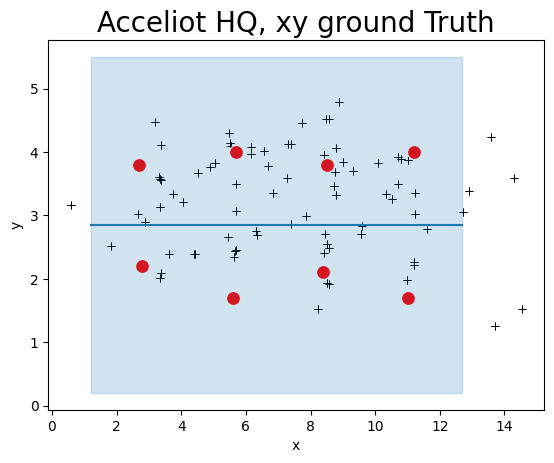

In [139]:
sns.scatterplot(data=Runs, x='x', y='y', marker='+', color='black')
sns.scatterplot(data=antConf, x='x_ant', y='y_ant', marker='o', color='red', s=100)
sns.lineplot(data=xy_tags, x='x', y='y')
plt.title('Acceliot HQ, xy ground Truth', size=20)


In [140]:
Runs[:1]

,ConfID,site,pgm,id,x,y,z0,P,run,xy,key
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,31.5,2026-02-04 21:23:51,1.82__2.51,1


Text(0.5, 1.0, 'z')

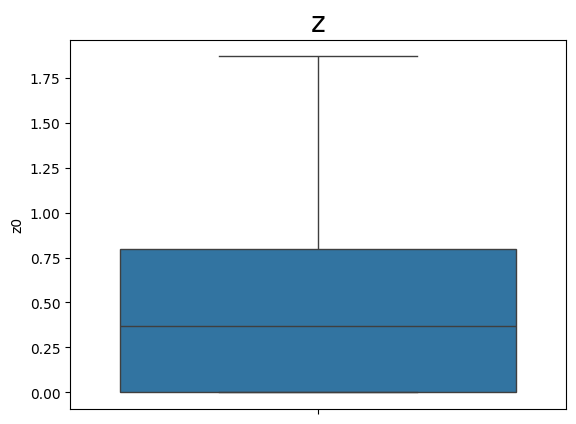

In [141]:
sns.boxplot(data=Runs, y='z0')
plt.title('z', size=20)

# pick

In [151]:
tags_pick = tags.copy()
tags.shape, tags_pick.shape

((728138, 31), (728138, 31))

## tag xy zone

In [152]:
x_ant_min = antConf['x_ant'].min()
x_ant_max = antConf['x_ant'].max()
y_ant_min = antConf['y_ant'].min()
y_ant_max = antConf['y_ant'].max()
(x_ant_min, x_ant_max), (y_ant_min, y_ant_max)

((2.7, 11.2), (1.7, 4.0))

In [153]:
(tags_pick['x'].min(), tags_pick['x'].max()), (tags_pick['y'].min(), tags_pick['y'].max()), (tags_pick['z'].min(), tags_pick['z'].max())

((0.58, 14.53), (1.26, 4.79), (0.05, 3.54))

In [154]:
(tags_pick['x'].max() - tags_pick['x'].min()) * (tags_pick['y'].max() - tags_pick['y'].min()) * (tags_pick['z'].max() - tags_pick['z'].min())

171.85981500000003

In [155]:
D_extra = 1.5

x_min=x_ant_min-D_extra
x_max = x_ant_max+D_extra
y_min = y_ant_min-D_extra
y_max = y_ant_max+D_extra

In [156]:
tags_pick.shape

(728138, 31)

In [157]:
tags_pick = tags_pick[ (tags_pick['x']>=x_min) & (tags_pick['x']<=x_max) & (tags_pick['y']>=y_min) & (tags_pick['y']<=y_max) ]
tags_pick.shape

(703780, 31)

## map

In [158]:
tags_pick['xy'] = tags_pick['x'].astype(str) + '__' + tags_pick['y'].astype(str)
xy_unique = tags_pick['xy'].nunique()
xy_unique

74

Text(0.5, 1.0, 'Acceliot HQ, xy ground Truth, 74 xy points')

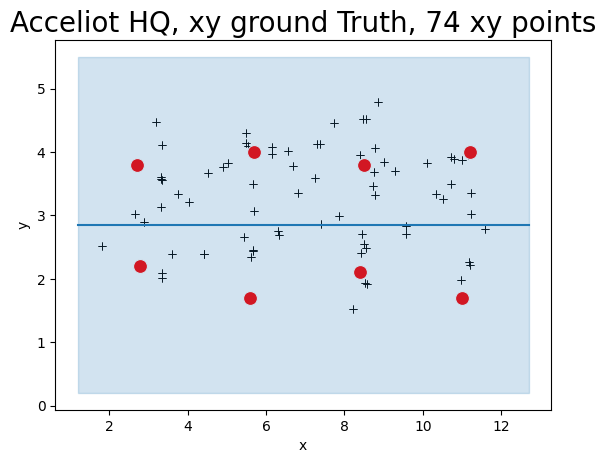

In [159]:
xy_tags = pd.DataFrame([[x_min, y_min], [x_min, y_max], [x_max, y_max], [x_max, y_min]], columns=['x', 'y'])
Runs_xy = Runs [ (Runs['x']>=x_min) & (Runs['x']<=x_max) & (Runs['y']>=y_min) & (Runs['y']<=y_max)]
sns.scatterplot(data=Runs_xy, x='x', y='y', marker='+', color='black')
sns.scatterplot(data=antConf, x='x_ant', y='y_ant', marker='o', color='red', s=100)
sns.lineplot(data=xy_tags, x='x', y='y')
plt.title(f'Acceliot HQ, xy ground Truth, {xy_unique} xy points', size=20)

In [160]:
Runs_xy['xy'].nunique()

74

## tag z

In [161]:
tags_pick['z'].describe()

,z
count,703780.000000
mean,1.391617
std,0.700829
min,0.050000
25%,0.960000
50%,1.340000
75%,1.810000
max,3.540000


In [162]:
z_min = 0.5
z_max=1.5

# z_min = 1.5
# z_max=4

# z_min = 0
# z_max=4

In [163]:
tags_pick.shape

(703780, 32)

In [164]:
tags_pick =  tags_pick [  (tags_pick['z']>=z_min) & (tags_pick['z']<=z_max) ]
tags_pick.shape

(310334, 32)

Text(0.5, 1.0, 'z')

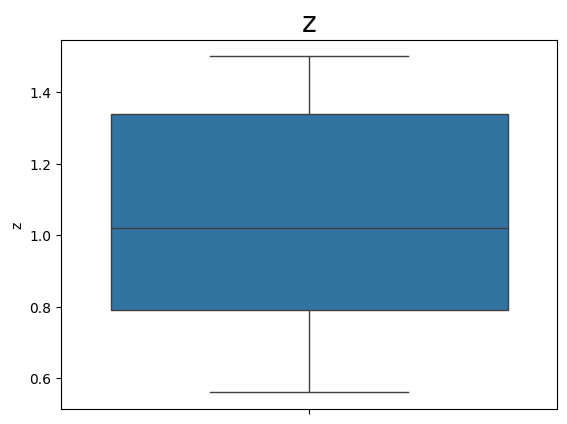

In [165]:
sns.boxplot(data=tags_pick, y='z')
plt.title('z', size=20)

## tag polarisation

In [ ]:
polar_list = ['H', 'V']
# polar_list = ['H']

In [ ]:
tags_pick.shape

In [ ]:
tags_pick =  tags_pick [ tags_pick['polar'].isin(polar_list) ]
tags_pick.shape

## Power

In [ ]:
Pmax_list=[24, 27, 31.5]
# Pmax_list=[31.5]
# Pmax_list=[24]

In [ ]:
tags_pick.shape

(310334, 31)

In [ ]:
tags_pick =  tags_pick [  tags_pick['txPower_dBm'].isin(Pmax_list) ]
tags_pick.shape

(310334, 31)

## run_duration

In [ ]:
tags_pick.shape

In [ ]:
run_duration=pd.Timedelta(seconds=20)

def func(df):
  Tstart=df['datestamp'].min()
  Tend=Tstart + run_duration
  df = df [ df['datestamp'] < Tend]
  return df

tags_pick = tags_pick.groupby('run').apply(func).reset_index(drop=True)
tags_pick.shape

# Stats

## detection per run

In [170]:
Detections = tags_pick.groupby(['x', 'y', 'z', 'xyz']) ['EPC'].nunique().rename('EPCs').reset_index(drop=False)
Detections[:1]

,x,y,z,xyz,EPCs
0,1.82,2.51,0.7,1.82__2.51__0.7,7


In [171]:
Detections['EPCs'].describe()

,EPCs
count,190.000000
mean,9.952632
std,0.277686
min,7.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [ ]:
Q_expected=10
# Q_expected=6
Detections['EPCs'].describe()['mean'] / Q_expected

np.float64(0.9934684684684685)

In [ ]:
MisDetections = Detections [Detections['EPCs']!=Q_expected]
MisDetections

In [ ]:
Detections_antRound = tags_pick.groupby(['run', 'xyz', 'antRound']) ['EPC'].nunique().rename('EPCs').reset_index(drop=False)
Detections_antRound['EPCs'].describe()

## Tx, TxRx

In [ ]:
tags_pick.groupby(['EPC', 'xyz'])['Tx'].nunique().describe()

,Tx
count,4411.000000
mean,5.591476
std,1.583778
min,1.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,8.000000


In [ ]:
tags_pick.groupby(['EPC', 'xyz', 'Tx'])['rx'].nunique().describe()

,rx
count,24664.000000
mean,3.579428
std,0.711933
min,2.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,4.000000


In [ ]:
tags_pick.columns

Index(['run', 'datestamp', 'EPC', 'txPower_dBm', 'Tx', 'rx', 'rssi (dBm)',
       'rssi', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi', 'Tx_sequence',
       'antRound', 'antRound_duration', 'slot_id', 'slotStart', 'x', 'y', 'z',
       'xyz', 'polar', '041A9F60__NONE', '041A9F61__NONE', '0F173B12__NONE',
       '0F173B13__NONE', 'PORT_1__NONE', 'PORT_2__NONE', 'PORT_3__NONE',
       'PORT_4__NONE', 'nearestAnt', 'nearestD', 'xy', 'Tx, rx'],
      dtype='object')

In [ ]:
tags_pick.groupby(['EPC', 'xyz', 'txPower_dBm'])['Tx'].nunique().groupby('txPower_dBm').describe()

,count,mean,std,min,25%,50%,75%,max
txPower_dBm,,,,,,,,
24.0,4192.0,2.879294,1.212254,1.0,2.0,3.0,4.0,7.0
27.0,4345.0,4.006214,1.447583,1.0,3.0,4.0,5.0,8.0
31.5,4395.0,5.442776,1.673807,1.0,4.0,6.0,7.0,8.0


In [ ]:
tags_pick['Tx, rx'] = tags_pick['Tx'] + ', '  + tags_pick['rx']
tags_pick.groupby(['EPC', 'xyz'])['Tx, rx'].nunique().describe()

,"Tx, rx"
count,4411.000000
mean,20.014282
std,6.468520
min,2.000000
25%,16.000000
50%,20.000000
75%,25.000000
max,32.000000


## rssimax = nearest?

In [168]:
index = ['EPC', 'run', 'xyz', 'Tx', 'txPower_dBm']
Values=['rssi']
ds_rssimax = pd.pivot_table(tags_pick, index=index, values=Values, aggfunc=max).rename(columns={'rssi':'rssimax'})
ds_rssimax = ds_rssimax.reset_index(drop=False)

ds_rssimax = pd.merge(ds_rssimax, Actuals_xyz_D, on=['xyz', 'EPC'])

ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)
print((ds_rssimax_1Tx['Tx'] == ds_rssimax_1Tx['nearestAnt']).mean())

for Tx in Tx_sequence.keys():
  idx_DTxMax = ds_rssimax_1Tx [ds_rssimax_1Tx['Tx']==Tx].index
  ds_rssimax_1Tx.loc[idx_DTxMax, 'DTxMax'] = ds_rssimax_1Tx.loc[idx_DTxMax, Tx]

ds_rssimax_1Tx['Delta_D'] = ds_rssimax_1Tx['DTxMax']-ds_rssimax_1Tx['nearestD']
ds_rssimax_1Tx['Delta_D'].describe()

/tmp/ipykernel_3193/2210509164.py:3: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ds_rssimax = pd.pivot_table(tags_pick, index=index, values=Values, aggfunc=max).rename(columns={'rssi':'rssimax'})


0.27392913802221047


/tmp/ipykernel_3193/2210509164.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)


,Delta_D
count,1891.000000
mean,0.681199
std,0.844290
min,0.000000
25%,0.000000
50%,0.453820
75%,1.042245
max,5.455754


In [169]:
ds_rssimax_1Tx

,EPC,run,xyz,Tx,txPower_dBm,rssimax,x,y,z,polar,...,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD,DTxMax,Delta_D
0,BA0101000000000000000000,2026-02-12 21:58:28,10.1__3.82__1.29,PORT_4__NONE,24.0,0.879023,10.10,3.82,1.29,H,...,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454,3.558160,0.496706
1,BA0101000000000000000000,2026-02-13 20:09:34,10.98__1.98__1.1300000000000001,0F173B12__NONE,31.5,0.024604,10.98,1.98,1.13,H,...,2.983236,3.765329,6.295371,4.139529,6.057698,3.787308,0F173B12__NONE,2.983236,2.983236,0.000000
2,BA0101000000000000000000,2026-02-05 22:58:19,11.01__3.87__1.08,PORT_2__NONE,31.5,0.088920,11.01,3.87,1.08,H,...,3.718790,3.228219,6.013768,3.775897,6.475291,4.230532,0F173B13__NONE,3.228219,3.775897,0.547678
3,BA0101000000000000000000,2026-02-12 22:03:49,11.16__3.95__1.07,0F173B12__NONE,27.0,0.033497,11.16,3.95,1.07,H,...,3.777433,3.230635,6.150041,3.886772,6.632119,4.364516,0F173B13__NONE,3.230635,3.777433,0.546798
4,BA0101000000000000000000,2026-02-12 22:09:23,11.19__2.26__0.91,0F173B12__NONE,24.0,0.143549,11.19,2.26,0.91,H,...,3.244349,3.810486,6.489052,4.306716,6.364102,4.092652,0F173B12__NONE,3.244349,3.244349,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1886,BA0510000000000000000000,2026-02-11 21:24:54,8.79__3.32__1.34,PORT_4__NONE,31.5,4.045759,8.79,3.32,1.34,H,...,3.889229,3.877125,4.069902,2.620706,4.399329,2.862534,PORT_2__NONE,2.620706,2.862534,0.241828
1887,BA0510000000000000000000,2026-02-10 21:15:22,8.79__4.06__1.34,PORT_1__NONE,31.5,2.494595,8.79,4.06,1.34,H,...,4.251035,3.817499,4.013141,2.589459,4.722213,3.247661,PORT_2__NONE,2.589459,4.013141,1.423682
1888,BA0510000000000000000000,2026-02-04 21:46:13,8.87__4.79__1.34,0F173B13__NONE,31.5,1.061696,8.87,4.79,1.34,H,...,4.658605,3.848974,4.150494,2.769585,5.176350,3.743074,PORT_2__NONE,2.769585,3.848974,1.079389
1889,BA0510000000000000000000,2026-02-06 21:43:05,9.01__3.85__1.34,0F173B12__NONE,31.5,3.483373,9.01,3.85,1.34,H,...,4.024947,3.685132,4.187147,2.610785,4.775374,3.160411,PORT_2__NONE,2.610785,4.024947,1.414162


## antRound

In [ ]:
tags_pick.groupby(['run', 'antRound'])['antRound_duration'].mean().describe()

## detections per antRound

In [ ]:
Detections_antRound = tags_pick.groupby(['x', 'y', 'z', 'xyz','txPower_dBm', 'antRound']) ['EPC'].nunique().rename('EPCs').reset_index(drop=False)
Detections_antRound['EPCs'].describe()

## visu

In [185]:
Slots[:1]

,run,slot_id,slotStart
0,2026-02-04 21:23:51,0,2026-02-04 21:23:50.645


BA0402000000000000000000 5.44__2.66__1.02 PORT_3__NONE 31.5 2026-02-17 21:39:19


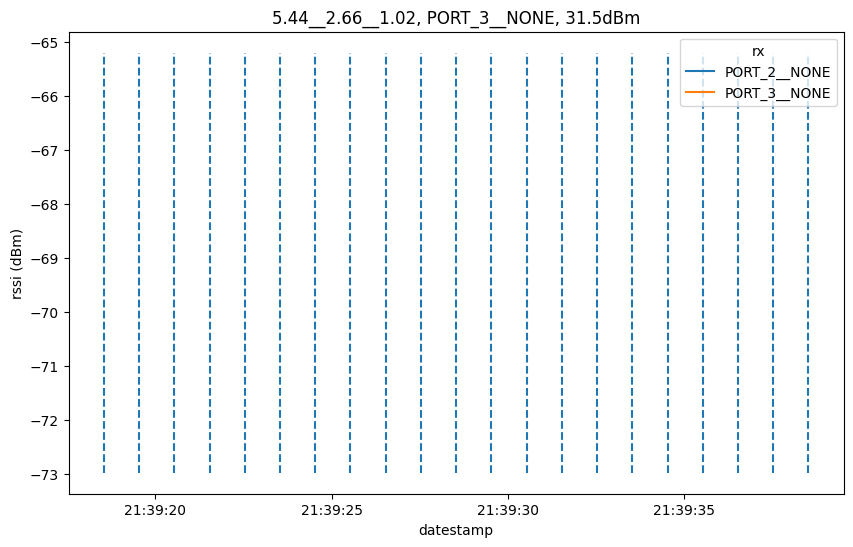

BA0308000000000000000000 3.34__2.01__0.7 041A9F60__NONE 31.5 2026-02-06 22:22:32


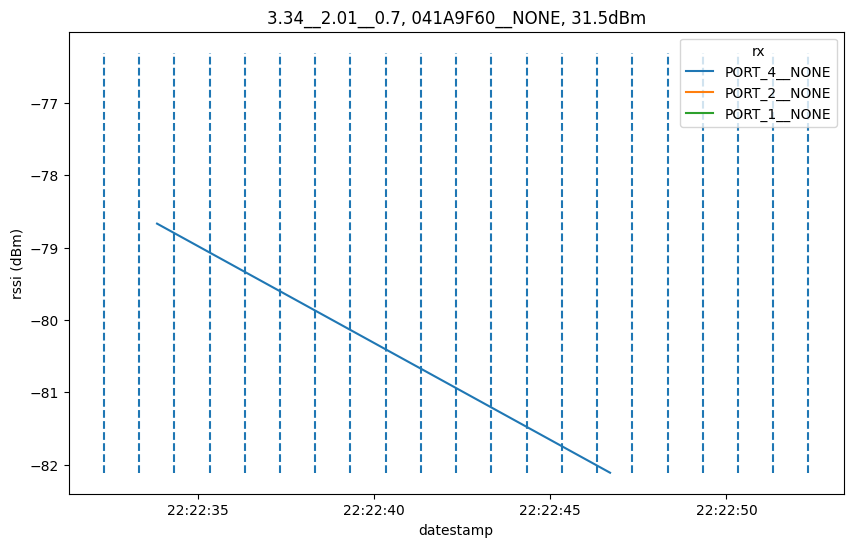

BA0207000000000000000000 3.36__3.56__1.5 PORT_1__NONE 27.0 2026-02-06 22:16:00


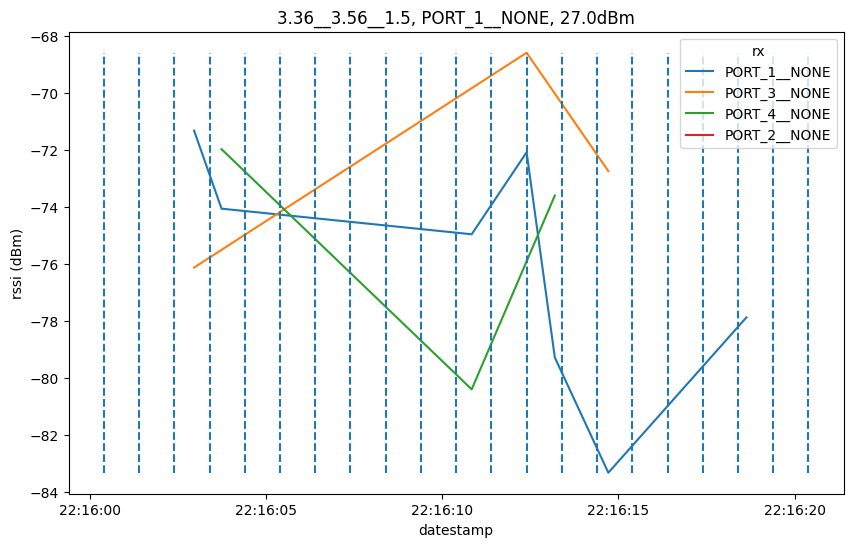

BA0110000000000000000000 8.52__1.93__0.8400000000000001 PORT_3__NONE 31.5 2026-02-06 21:47:29


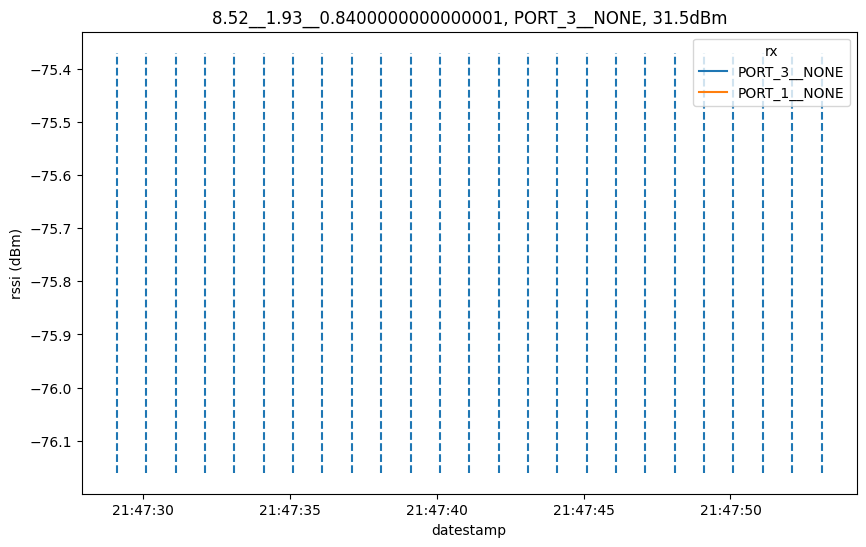

BA0310000000000000000000 8.45__2.7__0.7 PORT_4__NONE 31.5 2026-02-17 21:35:26


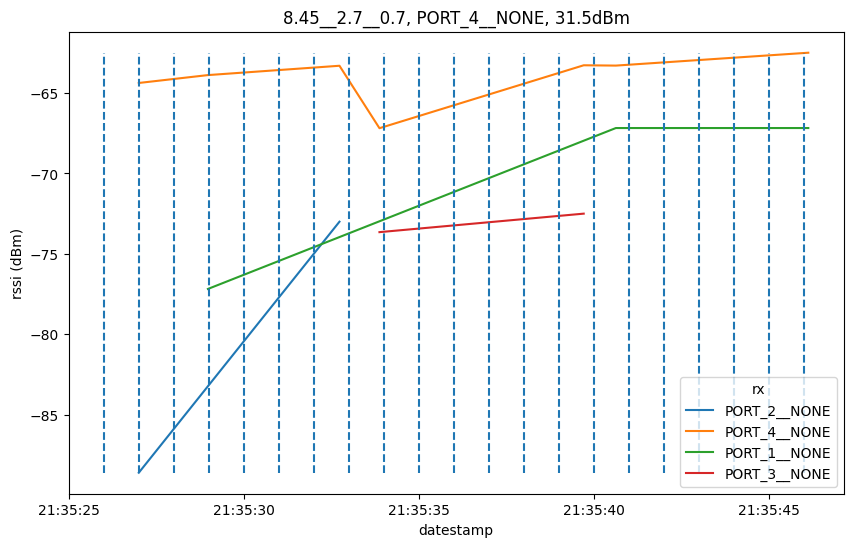

BA0402000000000000000000 8.79__4.06__1.02 0F173B13__NONE 27.0 2026-02-10 21:16:40


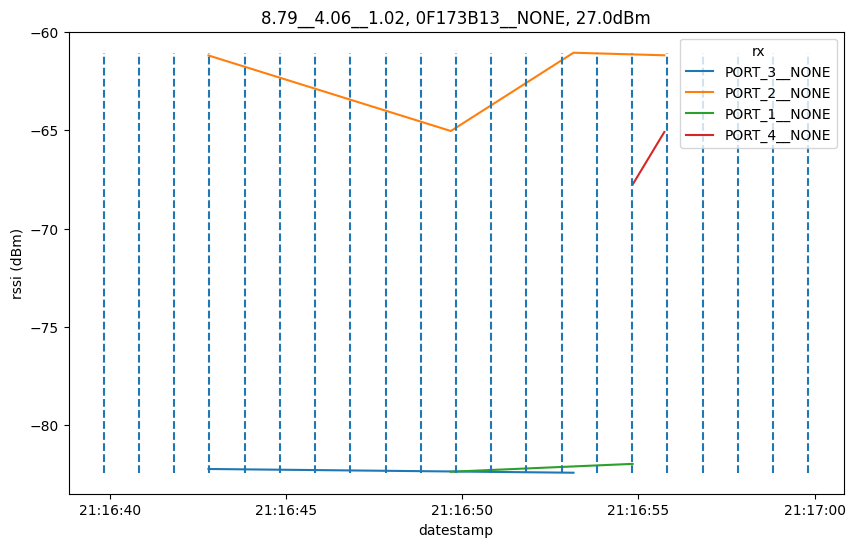

BA0103000000000000000000 5.68__2.46__1.28 PORT_2__NONE 24.0 2026-02-11 21:49:40


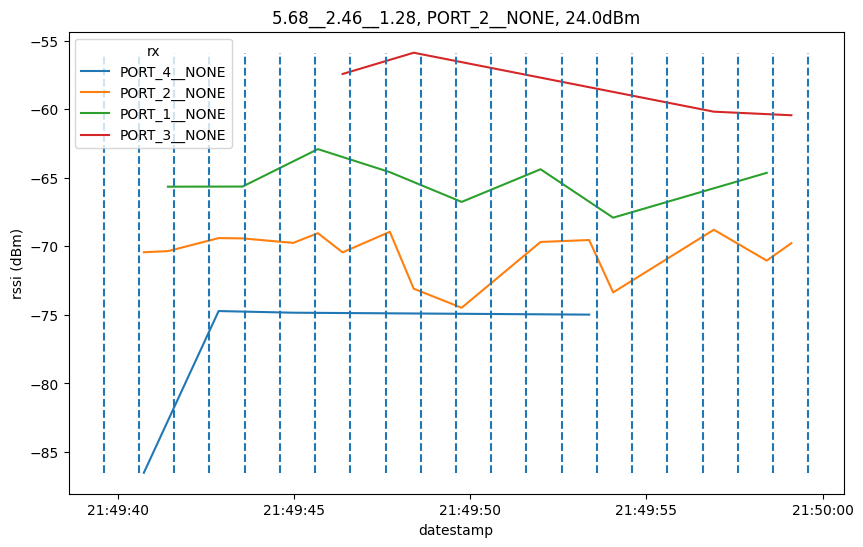

BA0103000000000000000000 11.59__2.78__0.9600000000000001 0F173B13__NONE 24.0 2026-02-05 22:41:18


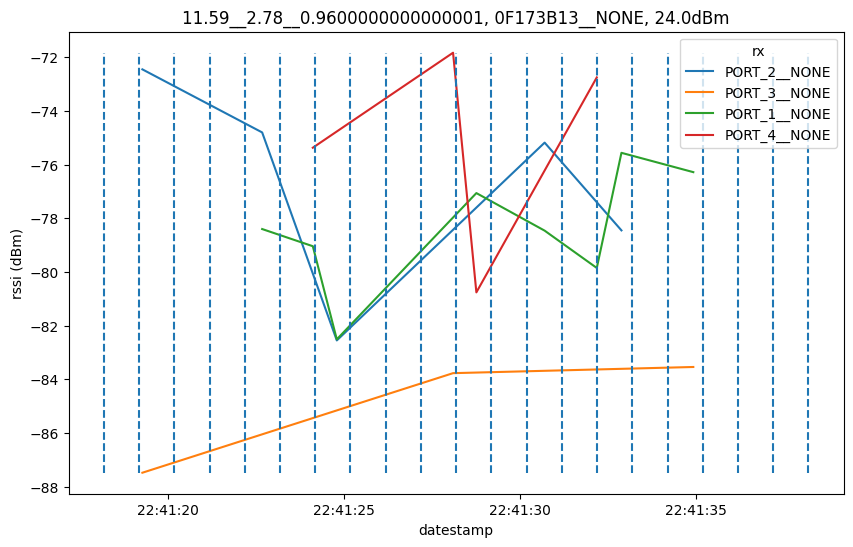

BA0404000000000000000000 8.79__3.32__1.02 PORT_3__NONE 31.5 2026-02-11 21:24:54


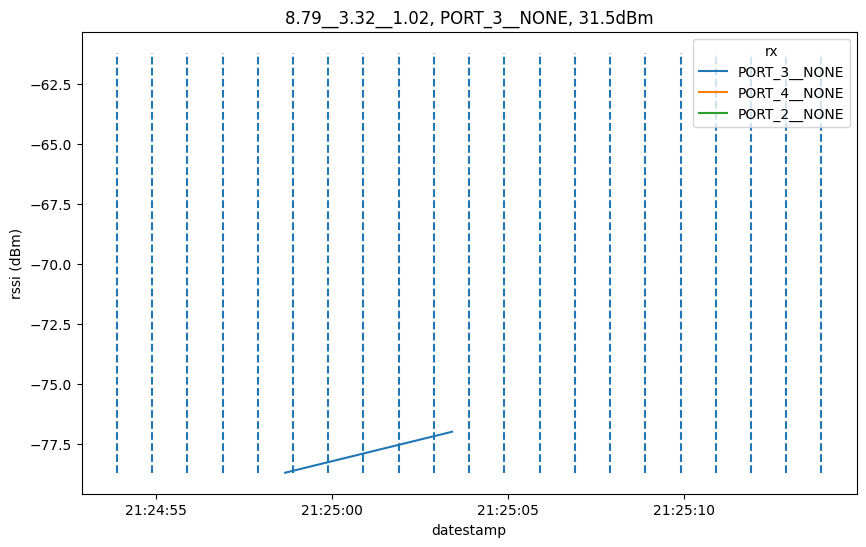

BA0107000000000000000000 4.41__2.39__0.74 PORT_2__NONE 31.5 2026-02-11 21:52:47


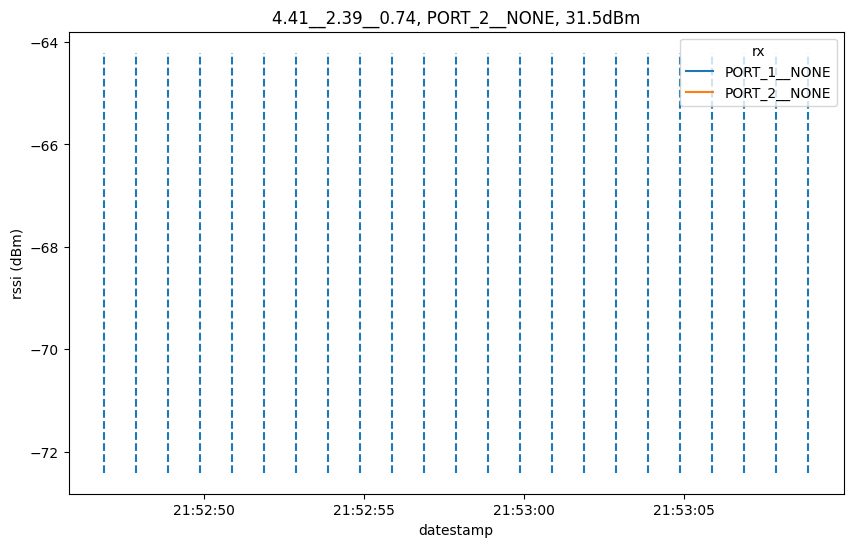

In [188]:
for i, row in tags_pick [['EPC', 'xyz', 'run', 'Tx', 'txPower_dBm']].drop_duplicates().sample(10).iterrows():
  EPC=row['EPC']
  xyz=row['xyz']
  Tx = row['Tx']
  txPower_dBm=row['txPower_dBm']
  run=row['run']

  tags_display = tags_pick [ (tags_pick['EPC']==EPC) & (tags_pick['xyz']==xyz) & (tags_pick['Tx']==Tx)& (tags_pick['txPower_dBm']==txPower_dBm) ]
  plt.figure(figsize=(10,6))
  print(EPC, xyz, Tx, txPower_dBm, run)
  sns.lineplot(data=tags_display, x='datestamp', y='rssi (dBm)', hue='rx')

  rssi_min = tags_display['rssi (dBm)'].min()
  rssi_max = tags_display['rssi (dBm)'].max()
  Slots_run = Slots [Slots['run']==run]
  plt.vlines(Slots_run['slotStart'], ymin=rssi_min, ymax=rssi_max, linestyles='--')
  plt.title(f'{xyz}, {Tx}, {txPower_dBm}dBm')
  plt.show()

## extreme samples

In [ ]:
ds_rssimax_1Tx

In [ ]:
hard = ds_rssimax_1Tx [ds_rssimax_1Tx['Delta_D']>3]

for i, row in hard.sample(10).iterrows():
  EPC=row['EPC']
  xyz=row['xyz']
  Tx = row['Tx']
  txPower_dBm=row['txPower_dBm']
  run=row['run']
  nearestD = row['nearestD']
  DTxMax = row['DTxMax']
  Delta_D = row['Delta_D']

  tags_display = tags_pick [ (tags_pick['EPC']==EPC) & (tags_pick['run']==run) ]
  plt.figure(figsize=(10,6))
  sns.lineplot(data=tags_display, x='datestamp', y='rssi (dBm)', hue='rx')

  rssi_min = tags_display['rssi (dBm)'].min()
  rssi_max = tags_display['rssi (dBm)'].max()
  Slots_run = Slots [Slots['run']==run]
  plt.vlines(Slots_run['slotStart'], ymin=rssi_min, ymax=rssi_max, linestyles='--')
  plt.title(f'{xyz}, {Tx}, {txPower_dBm}dBm, {DTxMax:.1f}, {nearestD:.1f}, {Delta_D:.1f}')
  plt.show()



In [ ]:
easy = ds_rssimax_1Tx [ds_rssimax_1Tx['Delta_D']<0.5]

for i, row in easy.sample(10).iterrows():
  EPC=row['EPC']
  xyz=row['xyz']
  Tx = row['Tx']
  txPower_dBm=row['txPower_dBm']
  run=row['run']
  nearestD = row['nearestD']
  DTxMax = row['DTxMax']
  Delta_D = row['Delta_D']

  tags_display = tags_pick [ (tags_pick['EPC']==EPC) & (tags_pick['run']==run) ]
  plt.figure(figsize=(10,6))
  sns.lineplot(data=tags_display, x='datestamp', y='rssi (dBm)', hue='rx')

  rssi_min = tags_display['rssi (dBm)'].min()
  rssi_max = tags_display['rssi (dBm)'].max()
  Slots_run = Slots [Slots['run']==run]
  plt.vlines(Slots_run['slotStart'], ymin=rssi_min, ymax=rssi_max, linestyles='--')
  plt.title(f'{xyz}, {Tx}, {txPower_dBm}dBm, {DTxMax:.1f}, {nearestD:.1f}, {Delta_D:.1f}')
  plt.show()





# ds

In [166]:
tags_pick[:1]

,run,datestamp,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),...,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD,xy
0,2026-02-04 21:23:51,2026-02-04 21:23:50.647,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,5.35,...,2.747017,9.620088,9.948171,4.881403,7.26912,4.636604,7.072348,041A9F60__NONE,2.482761,1.82__2.51


In [167]:
tags_pick.shape, tags_pick['xyz'].nunique()

((310334, 32), 190)

## basic: all Tx, no Rx

In [ ]:
index_pivot = ['EPC', 'xyz']


aggfunc_list=[max]
# aggfunc_list=[np.mean]
# aggfunc_list=[max, min]

Values=['rssi']
columns_pivot = ['txPower_dBm', 'Tx']
# columns_pivot = ['Tx']
fill_value=0
ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

Values=['Delta_rssi']
ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

ds = pd.concat([ds_rssi, ds_Delta_rssi], axis=1)

# ds = ds_rssi.copy()

ds = ds.fillna(0)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds
ds = ds.reset_index(drop=False)
ds.head()

In [ ]:
len(Xcols_ds)

In [ ]:
ds.shape, ds[Xcols_ds].shape[0]*ds[Xcols_ds].shape[1]

In [ ]:
(ds[Xcols_ds]==0).sum().sum()

In [ ]:
ds = pd.merge(ds, Actuals_xyz_D, on=['EPC', 'xyz'])
ds.head()

## advanced: (Tx, Rx)

In [209]:
index_pivot = ['EPC', 'xyz']

aggfunc_list=[max]
# aggfunc_list=[max, min]

Values=['rssi']
columns_pivot = ['txPower_dBm', 'Tx', 'rx']
fill_value=0
ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

# Values=['Delta_rssi']
# columns_pivot = ['txPower_dBm', 'Tx', 'rx1_rx2_ant']
# ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
#                               values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

# ds = pd.concat([ds_rssi, ds_Delta_rssi], axis=1)

ds = ds_rssi.copy()

ds = ds.fillna(0)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds
ds = ds.reset_index(drop=False)
ds.head()

/tmp/ipykernel_3193/2309303734.py:9: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \


,EPC,xyz,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE,max__rssi__24.0__041A9F60__NONE__PORT_2__NONE,max__rssi__24.0__041A9F60__NONE__PORT_3__NONE,max__rssi__24.0__041A9F60__NONE__PORT_4__NONE,max__rssi__24.0__041A9F61__NONE__PORT_1__NONE,max__rssi__24.0__041A9F61__NONE__PORT_2__NONE,max__rssi__24.0__041A9F61__NONE__PORT_3__NONE,max__rssi__24.0__041A9F61__NONE__PORT_4__NONE,...,max__rssi__31.5__PORT_2__NONE__PORT_3__NONE,max__rssi__31.5__PORT_2__NONE__PORT_4__NONE,max__rssi__31.5__PORT_3__NONE__PORT_1__NONE,max__rssi__31.5__PORT_3__NONE__PORT_2__NONE,max__rssi__31.5__PORT_3__NONE__PORT_3__NONE,max__rssi__31.5__PORT_3__NONE__PORT_4__NONE,max__rssi__31.5__PORT_4__NONE__PORT_1__NONE,max__rssi__31.5__PORT_4__NONE__PORT_2__NONE,max__rssi__31.5__PORT_4__NONE__PORT_3__NONE,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE
0,BA0101000000000000000000,10.1__3.82__1.29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.822243,0.074131,0.644169,0.066374,0.356451,0.023988,0.698232,0.172584,0.450817
1,BA0101000000000000000000,10.98__1.98__1.1300000000000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,BA0101000000000000000000,11.01__3.87__1.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.088920,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,BA0101000000000000000000,11.16__3.95__1.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002742,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,BA0101000000000000000000,11.19__2.26__0.91,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.039537,0.000000,0.000000,0.054828,0.022233,0.022909,0.000000,0.000000,0.013709,0.008872


In [210]:
len(Xcols_ds)

96

In [211]:
ds.shape, ds[Xcols_ds].shape[0]*ds[Xcols_ds].shape[1]

((1891, 98), 181536)

In [212]:
(ds[Xcols_ds]==0).sum().sum()

np.int64(101724)

In [213]:
Xcols_ds

['max__rssi__24.0__041A9F60__NONE__PORT_1__NONE',
 'max__rssi__24.0__041A9F60__NONE__PORT_2__NONE',
 'max__rssi__24.0__041A9F60__NONE__PORT_3__NONE',
 'max__rssi__24.0__041A9F60__NONE__PORT_4__NONE',
 'max__rssi__24.0__041A9F61__NONE__PORT_1__NONE',
 'max__rssi__24.0__041A9F61__NONE__PORT_2__NONE',
 'max__rssi__24.0__041A9F61__NONE__PORT_3__NONE',
 'max__rssi__24.0__041A9F61__NONE__PORT_4__NONE',
 'max__rssi__24.0__0F173B12__NONE__PORT_1__NONE',
 'max__rssi__24.0__0F173B12__NONE__PORT_2__NONE',
 'max__rssi__24.0__0F173B12__NONE__PORT_3__NONE',
 'max__rssi__24.0__0F173B12__NONE__PORT_4__NONE',
 'max__rssi__24.0__0F173B13__NONE__PORT_1__NONE',
 'max__rssi__24.0__0F173B13__NONE__PORT_2__NONE',
 'max__rssi__24.0__0F173B13__NONE__PORT_3__NONE',
 'max__rssi__24.0__0F173B13__NONE__PORT_4__NONE',
 'max__rssi__24.0__PORT_1__NONE__PORT_1__NONE',
 'max__rssi__24.0__PORT_1__NONE__PORT_2__NONE',
 'max__rssi__24.0__PORT_1__NONE__PORT_3__NONE',
 'max__rssi__24.0__PORT_1__NONE__PORT_4__NONE',
 'max__r

In [214]:
ds = pd.merge(ds, Actuals_xyz_D, on=['EPC', 'xyz'])
ds.head()

,EPC,xyz,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE,max__rssi__24.0__041A9F60__NONE__PORT_2__NONE,max__rssi__24.0__041A9F60__NONE__PORT_3__NONE,max__rssi__24.0__041A9F60__NONE__PORT_4__NONE,max__rssi__24.0__041A9F61__NONE__PORT_1__NONE,max__rssi__24.0__041A9F61__NONE__PORT_2__NONE,max__rssi__24.0__041A9F61__NONE__PORT_3__NONE,max__rssi__24.0__041A9F61__NONE__PORT_4__NONE,...,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,10.1__3.82__1.29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454
1,BA0101000000000000000000,10.98__1.98__1.1300000000000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.547614,8.830159,2.983236,3.765329,6.295371,4.139529,6.057698,3.787308,0F173B12__NONE,2.983236
2,BA0101000000000000000000,11.01__3.87__1.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.748909,8.683974,3.718790,3.228219,6.013768,3.775897,6.475291,4.230532,0F173B13__NONE,3.228219
3,BA0101000000000000000000,11.16__3.95__1.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.908030,8.831478,3.777433,3.230635,6.150041,3.886772,6.632119,4.364516,0F173B13__NONE,3.230635
4,BA0101000000000000000000,11.19__2.26__0.91,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.810891,9.038130,3.244349,3.810486,6.489052,4.306716,6.364102,4.092652,0F173B12__NONE,3.244349


In [215]:
ds.shape

(1891, 112)

In [216]:
Sample = ['EPC', 'x', 'y', 'z'] + Cols_D
ds [Sample]

,EPC,x,y,z,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE
0,BA0101000000000000000000,10.10,3.82,1.29,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160
1,BA0101000000000000000000,10.98,1.98,1.13,8.547614,8.830159,2.983236,3.765329,6.295371,4.139529,6.057698,3.787308
2,BA0101000000000000000000,11.01,3.87,1.08,8.748909,8.683974,3.718790,3.228219,6.013768,3.775897,6.475291,4.230532
3,BA0101000000000000000000,11.16,3.95,1.07,8.908030,8.831478,3.777433,3.230635,6.150041,3.886772,6.632119,4.364516
4,BA0101000000000000000000,11.19,2.26,0.91,8.810891,9.038130,3.244349,3.810486,6.489052,4.306716,6.364102,4.092652
...,...,...,...,...,...,...,...,...,...,...,...,...
1886,BA0510000000000000000000,8.79,3.32,1.34,6.499392,6.513532,3.889229,3.877125,4.069902,2.620706,4.399329,2.862534
1887,BA0510000000000000000000,8.79,4.06,1.34,6.666881,6.501023,4.251035,3.817499,4.013141,2.589459,4.722213,3.247661
1888,BA0510000000000000000000,8.87,4.79,1.34,6.975715,6.645043,4.658605,3.848974,4.150494,2.769585,5.176350,3.743074
1889,BA0510000000000000000000,9.01,3.85,1.34,6.811329,6.702701,4.024947,3.685132,4.187147,2.610785,4.775374,3.160411


In [217]:
print(Xcols_ds)

['max__rssi__24.0__041A9F60__NONE__PORT_1__NONE', 'max__rssi__24.0__041A9F60__NONE__PORT_2__NONE', 'max__rssi__24.0__041A9F60__NONE__PORT_3__NONE', 'max__rssi__24.0__041A9F60__NONE__PORT_4__NONE', 'max__rssi__24.0__041A9F61__NONE__PORT_1__NONE', 'max__rssi__24.0__041A9F61__NONE__PORT_2__NONE', 'max__rssi__24.0__041A9F61__NONE__PORT_3__NONE', 'max__rssi__24.0__041A9F61__NONE__PORT_4__NONE', 'max__rssi__24.0__0F173B12__NONE__PORT_1__NONE', 'max__rssi__24.0__0F173B12__NONE__PORT_2__NONE', 'max__rssi__24.0__0F173B12__NONE__PORT_3__NONE', 'max__rssi__24.0__0F173B12__NONE__PORT_4__NONE', 'max__rssi__24.0__0F173B13__NONE__PORT_1__NONE', 'max__rssi__24.0__0F173B13__NONE__PORT_2__NONE', 'max__rssi__24.0__0F173B13__NONE__PORT_3__NONE', 'max__rssi__24.0__0F173B13__NONE__PORT_4__NONE', 'max__rssi__24.0__PORT_1__NONE__PORT_1__NONE', 'max__rssi__24.0__PORT_1__NONE__PORT_2__NONE', 'max__rssi__24.0__PORT_1__NONE__PORT_3__NONE', 'max__rssi__24.0__PORT_1__NONE__PORT_4__NONE', 'max__rssi__24.0__PORT_2__N

In [218]:
EPC = 'BA0103000000000000000000'
xyz = '5.68__2.46__1.28'
Tx = 'PORT_2__NONE'
txPower_dBm = 24.0
run = pd.to_datetime('2026-02-11 21:49:40')
ds_pick = ds[ (ds['EPC']==EPC) & (ds['xyz']==xyz) ]
Xcols_ds_pick = ['max__rssi__24.0__PORT_2__NONE__PORT_1__NONE', 'max__rssi__24.0__PORT_2__NONE__PORT_2__NONE', 'max__rssi__24.0__PORT_2__NONE__PORT_3__NONE', 'max__rssi__24.0__PORT_2__NONE__PORT_4__NONE']
10*np.log10(ds_pick[Xcols_ds_pick]*10**(-6))

,max__rssi__24.0__PORT_2__NONE__PORT_1__NONE,max__rssi__24.0__PORT_2__NONE__PORT_2__NONE,max__rssi__24.0__PORT_2__NONE__PORT_3__NONE,max__rssi__24.0__PORT_2__NONE__PORT_4__NONE
78,-62.91,-68.79,-55.88,-74.72


In [219]:
[x.split('__')[-1] for x in Xcols_ds_pick]

['NONE', 'NONE', 'NONE', 'NONE']

## per Tx, all rx

tags_pick: txPower=31.5 only + duration=2sec

In [ ]:
index_pivot = ['EPC', 'run', 'xyz', 'txPower_dBm', 'Tx' ]

aggfunc_list=[max]
# aggfunc_list=[max, min]

Values=['rssi']
columns_pivot = ['rx']
fill_value=0
ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

Values=['Delta_rssi']
columns_pivot = ['rx1_rx2_ant']
ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

ds = pd.concat([ds_rssi, ds_Delta_rssi], axis=1)

# ds = ds_rssi.copy()

ds = ds.fillna(0)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds
ds = ds.reset_index(drop=False)
ds.head()

### check at least 10 samples (train_test_split) per txPower, Tx, rx

In [ ]:
ds.groupby(['Tx', 'txPower_dBm']).size().describe()

In [ ]:
ds.shape

In [ ]:
size = ds.groupby(['Tx', 'txPower_dBm']).size().rename('size').reset_index(drop=False)
ds = pd.merge(ds, size, on=['Tx', 'txPower_dBm'])
ds = ds [ds['size']>=10]
ds.shape


In [ ]:
ds = pd.merge(ds, Actuals_xyz_D_run.drop(columns=['xyz']), on=['EPC', 'run'])
ds.head()

In [ ]:
ds.shape

In [ ]:
Xcols_ds

In [ ]:
index=['run', 'EPC', 'Tx', 'txPower_dBm']
columns=['rx']
Values=['rssi']

aggfunc=[max]

ds = pd.pivot_table(tags_pick, index=index, columns=columns, values=Values, aggfunc=aggfunc, fill_value=0)
Xcols_ds = ['_'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds
ds = ds.reset_index(drop=False)
ds.head()

In [ ]:
Actuals_xyz_D_run[:1]

In [ ]:
ds.shape

In [ ]:
# ds_temp = pd.merge(ds_temp, Actuals_xyz_D_run, on=['EPC', 'run'])
# ds_temp.shape

ds = pd.merge(ds, Actuals_xyz_D_run, on=['EPC', 'run'])
ds.head()

In [ ]:
ds.shape

In [ ]:
def func(df):
  Tx=df['Tx'].values[0]
  df['TxD'] = df[Tx]
  return df
ds = ds.groupby('Tx').apply(func).reset_index(drop=True)
ds.head()

In [ ]:
ds['TxD'].describe()

In [ ]:
ds.head()

In [ ]:
ds[['EPC', 'x', 'y', 'z', 'Tx', 'TxD', 'PORT_1__NONE', 'PORT_2__NONE', 'PORT_3__NONE', 'PORT_4__NONE']]

In [ ]:
ds[['EPC', 'x', 'y', 'z', 'txPower_dBm', 'Tx'] + Xcols_ds]

In [ ]:
Xcols_ds

In [ ]:
tags_pick[:2]

In [ ]:
# PX
aggfunc_list = [max, min]
index_pivot = ['EPC', 'xyz']

# columns_pivot = ['txPower_dBm', 'Tx', 'rx']
columns_pivot = ['txPower_dBm', 'Tx']
# Values=['rssi']
Values=['rssi']

ds = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=0)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds

ds = ds.reset_index(drop=False)
ds.head()

In [ ]:
ds.shape

In [ ]:
tags_pick['rx1_rx2_ant'].unique()

In [ ]:
# PX
aggfunc_list = [max]
index_pivot = ['EPC', 'xyz']
# columns_pivot = ['txPower_dBm', 'Tx', 'rx']
columns_pivot = ['txPower_dBm', 'Tx']
Values=['rssi']
ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=0)

# columns_pivot = ['txPower_dBm', 'Tx', 'rx1_rx2_ant']
columns_pivot = ['txPower_dBm', 'Tx']

Values=['Delta_rssi']
ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=0)

ds = pd.concat([ds_rssi, ds_Delta_rssi], axis=1)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds

ds = ds.reset_index(drop=False)

ds = ds.fillna(0)
ds.head()

In [ ]:
ds.shape

In [ ]:
ds = pd.merge(ds, Actuals_xyz_D, on=['EPC', 'xyz'])
ds.head()

In [ ]:
ds.shape

In [ ]:
len(Xcols_ds)

In [ ]:
# file='ds_Tx_Rx.csv'
file='ds_elemen.csv'
ds.to_csv(file, index=False)
temp = pd.read_csv(file)
Xcols_ds = [x for x in temp.columns if 'rssi' in x]
len(Xcols_ds)

In [ ]:
(ds==0).sum().sum()

In [ ]:
ds.shape

In [ ]:
tags_pick[:2]

In [ ]:
# PX
# aggfunc_list = [max, min, np.mean]
aggfunc_list = [max, min]
# aggfunc_list = [max]
# aggfunc_list = [np.mean]
# aggfunc_list = [max]

index_pivot = ['EPC', 'xyz']
columns_pivot = ['txPower_dBm', 'Tx']
Values = ['rssi1', 'rssi2', 'Delta_rssi']

ds = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds

ds = ds.reset_index(drop=False)

ds = ds.fillna(0)
ds.head()

In [ ]:
ds.shape

In [ ]:
(ds[Xcols_ds]==0).sum().sum()

### merge with Actuals_xyz_D

In [ ]:
ds = pd.merge(ds, Actuals_xyz_D, on=['EPC', 'xyz'])
ds.shape

In [ ]:
# file='ds_basic_18Feb26.csv'
# ds.to_csv(file, index=False)
# temp = pd.read_csv(file)
# Xcols_ds_lin = [x for x in temp.columns if 'rssi' in x]
# len(Xcols_ds_lin)

# **multiple Regressors**


In [ ]:
# # Regression (RF, ET, GB, KNN, Ridge, DecisionTree, NN)

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


X_reg = ds[Xcols_ds].values
y_reg = ds[['x', 'y', 'z']].values
idx_all = ds.index.to_numpy()   # keep track of original indices

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_reg, y_reg, idx_all,
    test_size=0.2,
    random_state=0
)


# # Define candidate regressors

regressors = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=0),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(random_state=0),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Ridge": Ridge(alpha=1.0),
    "DecisionTree": DecisionTreeRegressor(random_state=0),
    "NN": MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        random_state=0,
        max_iter=1000,
        early_stopping=True
    ),
}

reg_results = {}    # RMSE per model
reg_errors = {}     # per-sample 3D distance error per model
y_pred_store = {}   # store predictions per model
best_model = None   # trained RandomForest model


for name, base_reg in regressors.items():
    model = MultiOutputRegressor(base_reg)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    # 3D RMSE on (x, y, z)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    reg_results[name] = rmse

    # per-sample Euclidean distance in 3D
    dists = np.linalg.norm(y_pred - y_test, axis=1)
    reg_errors[name] = dists

    # store predictions for later analysis (Task 3 & 4)
    y_pred_store[name] = y_pred

    print(
        f"{name}: 3D RMSE = {rmse:.3f} m, "
        f"mean |error| = {dists.mean():.3f} m, "
        f"median |error| = {np.median(dists):.3f} m"
    )

    # keep RandomForest as final model if it is good otherwise change it
    if name == "RandomForest":
         best_model = model

reg_results


# BEST regressor

## Values

In [220]:
Values_xyz = ['x', 'y', 'z']
# Values_xyz = ['x', 'y']
Values_xyz_pred = [x+'_pred' for x in Values_xyz]

# Values_D = Cols_D
# Values_D =  ['TxD', 'PORT_1__NONE', 'PORT_2__NONE', 'PORT_3__NONE', 'PORT_4__NONE']
# Values_D_pred = [x+'_pred' for x in Values_D]

In [221]:
# Values_pick = Values_xyz
# Values_pick = Cols_D
Values_pick = Values_xyz + Cols_D
Values_pick_pred = [x+'_pred' for x in Values_pick]

In [222]:
Values_pick

['x',
 'y',
 'z',
 '041A9F60__NONE',
 '041A9F61__NONE',
 '0F173B12__NONE',
 '0F173B13__NONE',
 'PORT_1__NONE',
 'PORT_2__NONE',
 'PORT_3__NONE',
 'PORT_4__NONE']

In [223]:
Values_pick_pred

['x_pred',
 'y_pred',
 'z_pred',
 '041A9F60__NONE_pred',
 '041A9F61__NONE_pred',
 '0F173B12__NONE_pred',
 '0F173B13__NONE_pred',
 'PORT_1__NONE_pred',
 'PORT_2__NONE_pred',
 'PORT_3__NONE_pred',
 'PORT_4__NONE_pred']

## Tx, (Tx, Rx)

### train_test_split, Kfold=5

shuffle

In [224]:
ds = ds.sample(frac=1).reset_index(drop=True)
ds.shape, len(Xcols_ds)

((1891, 112), 96)

In [225]:
# clf = RandomForestRegressor()
# clf = KNeighborsRegressor(n_neighbors=5)
clf = ExtraTreesRegressor()
target = Values_pick
target_pred = Values_pick_pred
for ds_test in np.array_split(ds, 5):
  idx_test = ds_test.index
  idx_train = [x for x in ds.index if x not in idx_test]
  ds_train = ds.loc[idx_train]
  X_train = ds_train.loc[:, Xcols_ds]
  X_test = ds_test.loc[:, Xcols_ds]
#

  y_train = ds_train.loc[:, target]
  y_test = ds_test.loc[:, target]
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)

  ds.loc[idx_test, target_pred] = y_pred

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [226]:
mse = mean_squared_error(ds[target].values, ds[target_pred].values)
rmse = np.sqrt(mse)
rmse

np.float64(0.6299724274681717)

In [227]:
np.sqrt(mean_squared_error(ds[target].values, ds[target_pred].values, multioutput='raw_values'))

array([0.88671997, 0.65779272, 0.25830176, 0.67163174, 0.67692852,
       0.7024555 , 0.70363398, 0.49514244, 0.57508725, 0.52145969,
       0.57806312])

In [228]:
ds['err'] = [np.sqrt((x**2).sum()) for x in (ds[Values_xyz].values-ds[Values_xyz_pred].values)]
ds['err'].describe()

,err
count,1891.000000
mean,0.986080
std,0.559906
min,0.039639
25%,0.606772
50%,0.857679
75%,1.234353
max,4.695959


In [229]:
mse = mean_squared_error(ds[Values_xyz].values, ds[Values_xyz_pred].values)
rmse = np.sqrt(mse)
rmse

np.float64(0.6546457982800403)

In [230]:
ds[ds['err']<1].shape[0]/ds.shape[0], ds[ds['err']<2].shape[0]/ds.shape[0], ds[ds['err']<3].shape[0]/ds.shape[0]

(0.6017979904812268, 0.9439450026441036, 0.9931253305129562)

In [ ]:
len(Xcols_ds)

192

## per Tx, txPower, all rx

In [ ]:
ds.head()

In [ ]:
ds.groupby(['txPower_dBm', 'Tx']).size().describe()

In [ ]:
ds = ds.sample(frac=1).reset_index(drop=True)
ds.shape, len(Xcols_ds)

In [ ]:
def func(df):
  clf = ExtraTreesRegressor()
  target = Values_pick
  target_pred = Values_pick_pred
  for ds_test in np.array_split(df, 5):
    idx_test = ds_test.index
    idx_train = [x for x in df.index if x not in idx_test]
    ds_train = df.loc[idx_train]
    X_train = ds_train.loc[:, Xcols_ds]
    X_test = ds_test.loc[:, Xcols_ds]
#

    y_train = ds_train.loc[:, target]
    y_test = ds_test.loc[:, target]
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df.loc[idx_test, target_pred] = y_pred
  return df


ds = ds.groupby(['txPower_dBm', 'Tx']).apply(func).reset_index(drop=True)
ds.head()

In [ ]:
ds.groupby(['txPower_dBm', 'Tx' ]).apply(lambda x:mean_squared_error(x[Values_pick].values, x[Values_pick_pred].values)).rename('rmse')

In [ ]:
ds.groupby(['txPower_dBm', 'Tx' ]).apply(lambda x:mean_squared_error(x[Values_pick].values, x[Values_pick_pred].values)).describe()

In [ ]:
ds['err'] = [np.sqrt((x**2).sum()) for x in (ds[Values_xyz].values-ds[Values_xyz_pred].values)]
ds['err'].describe()

In [ ]:
ds[ds['err']<1].shape[0]/ds.shape[0], ds[ds['err']<2].shape[0]/ds.shape[0], ds[ds['err']<3].shape[0]/ds.shape[0]

In [ ]:
ds.groupby(['EPC', 'xyz']).size().describe()

In [ ]:
final = ds.groupby(['EPC', 'xyz']+Values_pick)[Values_pick_pred].mean().reset_index(drop=False)
final

mse = mean_squared_error(final[Values_pick].values, final[Values_pick_pred].values)
rmse = np.sqrt(mse)
rmse

In [ ]:
final['err'] = [np.sqrt((x**2).sum()) for x in (final[Values_xyz].values-final[Values_xyz_pred].values)]
final['err'].describe()

In [ ]:
# file='ds_9March26.csv'
# ds.to_csv(file, index=False)
# temp = pd.read_csv(file)
# Xcols_ds = [x for x in temp.columns if 'max_PORT' in x]
# len(Xcols_ds)

# ANNEX

In [ ]:
# import numpy as np
# from sklearn.metrics import mean_squared_error

# cols_xyz = ['x','y','z']

# diff_xyz = y_pred[:, :3] - y_test[cols_xyz].values

# err_3d = np.linalg.norm(diff_xyz, axis=1)
# rmse_3d = np.sqrt(np.mean(err_3d**2))
# mean_err = np.mean(err_3d)
# median_err = np.median(err_3d)

# rmse_xyz = np.sqrt(mean_squared_error(y_test[cols_xyz].values, y_pred[:, :3]))

# print(f"3D RMSE (xyz only) = {rmse_3d:.3f} m")
# print(f"mean |error| = {mean_err:.3f} m, median |error| = {median_err:.3f} m")
# print(f"Per-axis RMSE over xyz = {rmse_xyz:.3f} m")
# print(f"Check: sqrt(3)*PerAxis_RMSE = {np.sqrt(3)*rmse_xyz:.3f} m")


In [ ]:

# # # METRICS (RMSE & ANTENNA ACCURACY)

# print("\n METRICS (RMSE & ANTENNA ACCURACY)")

# def to_array(data):
#     if hasattr(data, 'values'):
#         return data.values
#     return data

# # # Calculate Nearest Antenna Accuracy
# y_test_arr = to_array(y_test)
# y_pred_arr = to_array(y_pred)
# ant_coords_arr = to_array(antConf[['x', 'y', 'z']])

# # # (True vs Pred)
# true_nearest = get_nearest_antenna(y_test_arr, ant_coords_arr)
# pred_nearest = get_nearest_antenna(y_pred_arr, ant_coords_arr)

# # # Accuracy
# ant_acc = accuracy_score(true_nearest, pred_nearest)

# # # Compute RMSE
# rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))

# print(f"{'Metric':<30} | {'Value':<10}")
# print("-" * 45)
# print(f"{'RMSE (RF)':<30} | {rmse_rf:.4f} m")
# print(f"{'Nearest Antenna Accuracy':<30} | {ant_acc:.2%}")

In [ ]:
# def build_error_df(model_name="RandomForest"):
#     """
#     Returns a DataFrame with, for each test sample:
#     - original ds index
#     - true (x,y,z)
#     - predicted (x,y,z)
#     - 3D error (Euclidean distance)
#     """
#     if model_name not in y_pred_store:
#         raise ValueError(
#             f"Unknown model '{model_name}'. Available: {list(y_pred_store.keys())}"
#         )

#     y_pred = y_pred_store[model_name]
#     dists = reg_errors[model_name]

#     # Build DataFrame
#     df_err = pd.DataFrame({
#         "ds_index": idx_test,
#         "x_true": y_test[:, 0],
#         "y_true": y_test[:, 1],
#         "z_true": y_test[:, 2],
#         "x_pred": y_pred[:, 0],
#         "y_pred": y_pred[:, 1],
#         "z_pred": y_pred[:, 2],
#         "error_3D": dists,
#     })

#     # Sort by descending error
#     df_err = df_err.sort_values(
#         by="error_3D", ascending=False
#     ).reset_index(drop=True)

#     return df_err


In [ ]:
# df_err_nn = build_error_df("NN")
# df_err_nn.head()

# df_err_rf = build_error_df("RandomForest")
# df_err_nn.head()

# def show_worst_samples(model_name="RandomForest", k=5):
#     df_err = build_error_df(model_name)
#     worst = df_err.head(k)

#     print(f"Worst {k} samples for model: {model_name}")
#     display(worst)

#     cols_to_show = ["EPC", "run"] if all(c in ds.columns for c in ["EPC", "run"]) else []
#     if cols_to_show:
#         display(
#             worst.merge(
#                 ds[cols_to_show],
#                 left_on="ds_index",
#                 right_index=True,
#                 how="left"
#             )
#         )

# show_worst_samples("NN", k=5)

# from mpl_toolkits.mplot3d i/

# import numpy as np

# def cell_accuracy(y_true, y_pred, cell_size):
#     y_true = np.asarray(y_true)
#     y_pred = np.asarray(y_pred)

#     true_snapped = np.round(y_true / cell_size) * cell_size
#     pred_snapped = np.round(y_pred / cell_size) * cell_size

#     same_cell = np.all(true_snapped == pred_snapped, axis=1)
#     return same_cell.mean()

# def report_cell_accuracies(model_name="RandomForest", cell_sizes=(2.0, 1.0, 0.5)):
#     y_pred = y_pred_store[model_name]
#     print(f"Cell accuracy for model: {model_name}")
#     for G in cell_sizes:
#         acc = cell_accuracy(y_test, y_pred, G)
#         print(f"  grid {G:.2f} m: {acc*100:.1f}% of test points in correct cell")

# report_cell_accuracies("RandomForest", cell_sizes=(2.0, 1.0, 0.5))
# report_cell_accuracies("NN", cell_sizes=(2.0, 1.0, 0.5))

# radii = [0.5, 1.0, 1.5, 2.0]

# for name, dists in reg_errors.items():
#     print(f"\n{name}:")
#     for R in radii:
#         frac = (dists <= R).mean()
#         print(f"  within {R:.1f} m: {frac*100:.1f}% of test points")

In [ ]:
# def visu(df, EPC='all', max_points_per_combo=800):
#     """
#     Visualize RSSI vs time for all (Tx,Rx) pairs.

#     EPC:  'all'  → all tags
#           <EPC string> → only that tag

#     max_points_per_combo: if not None, randomly subsample per (Tx,Rx)
#                           to reduce clutter.
#     """
#     import matplotlib.pyplot as plt

#     plt.rcParams.update({'axes.labelsize': 16,
#                          'xtick.labelsize': 14,
#                          'ytick.labelsize': 14})

#     # -------- Styles per (Tx,Rx) --------
#     # Colors are helpers; marker shapes carry the main information.
#     dict_styles = {
#         (1, 1): dict(marker='o',  color='tab:blue',    label='T1R1'),
#         (1, 2): dict(marker='s',  color='tab:orange',  label='T1R2'),
#         (1, 3): dict(marker='^',  color='tab:green',   label='T1R3'),
#         (1, 4): dict(marker='X',  color='tab:red',     label='T1R4'),

#         (2, 1): dict(marker='D',  color='tab:purple',  label='T2R1'),
#         (2, 2): dict(marker='v',  color='tab:brown',   label='T2R2'),
#         (2, 3): dict(marker='P',  color='tab:pink',    label='T2R3'),
#         (2, 4): dict(marker='*',  color='tab:gray',    label='T2R4'),

#         (3, 1): dict(marker='h',  color='tab:cyan',    label='T3R1'),
#         (3, 2): dict(marker='H',  color='tab:olive',   label='T3R2'),
#         (3, 3): dict(marker='<',  color='tab:blue',    label='T3R3'),
#         (3, 4): dict(marker='>',  color='tab:orange',  label='T3R4'),

#         (4, 1): dict(marker='8',  color='tab:green',   label='T4R1'),
#         (4, 2): dict(marker='p',  color='tab:red',     label='T4R2'),
#         (4, 3): dict(marker='x',  color='tab:purple',  label='T4R3'),
#         (4, 4): dict(marker='+',  color='tab:brown',   label='T4R4'),
#     }

#     # -------- Filter by EPC if needed --------
#     if EPC != 'all':
#         df = df[df['EPC'] == EPC]

#     if df.empty:
#         print("No data for this EPC.")
#         return

#     Tmax = df['datestamp'].max()
#     Tmin = df['datestamp'].min()
#     RSSImax = df['RSSI (dBm)'].max()
#     RSSImin = df['RSSI (dBm)'].min()

#     detections = len(df)
#     EPCs_unique = df['EPC'].nunique()

#     x_min = Tmin - pd.Timedelta(1, unit='s')
#     x_max = Tmax + pd.Timedelta(1, unit='s')

#     fig, ax = plt.subplots(figsize=(14, 6))

#     # -------- Plot each (Tx,Rx) --------
#     for (Tx, Rx), df_TxRx in df.groupby(['Tx', 'Rx']):
#         style = dict_styles.get(
#             (Tx, Rx),
#             dict(marker='o', color='black', label=f'T{Tx}R{Rx}')
#         )

#         # Subsample to avoid huge clouds
#         if max_points_per_combo is not None and len(df_TxRx) > max_points_per_combo:
#             df_plot = df_TxRx.sample(max_points_per_combo, random_state=0)
#         else:
#             df_plot = df_TxRx

#         ax.scatter(
#             df_plot['datestamp'],
#             df_plot['RSSI (dBm)'],
#             marker=style['marker'],
#             s=15,              # slightly smaller markers
#             alpha=0.6,
#             edgecolors='none',
#             color=style['color'],
#             label=style['label']
#         )

#     # -------- Titles & axes --------
#     title = f'EPC={EPC}, detections={detections}'
#     if EPC == 'all':
#         title += f', EPCs_unique={EPCs_unique}'
#     ax.set_title(title, size=16)

#     ax.set_xlim(x_min, x_max)
#     ax.set_ylim(RSSImin - 1, RSSImax + 1)
#     ax.set_ylabel('RSSI (dBm)')
#     ax.set_xlabel('datestamp')

#     # -------- Legend (unique labels) --------
#     handles, labels = ax.get_legend_handles_labels()
#     by_label = dict(zip(labels, handles))
#     ax.legend(by_label.values(),
#               by_label.keys(),
#               bbox_to_anchor=(1.02, 1),
#               loc='upper left',
#               fontsize=8,
#               title='Tx-Rx')

#     plt.tight_layout()
#     plt.show()

In [ ]:
# for run in tags['run'].unique():
# # for run in tags['run'].unique():
#   # print(Runs[Runs['run']==run][ ['x', 'y', 'z']] )
#   # tags_run = tags [ (tags['run'] == run)    ]
#   tags_run = tags [ (tags['run'] == run)     ]

#   visu(tags_run, 'all')


# for run in pd.Series(tags['run'].unique()).sample(1):
# # for run in tags['run'].unique():
#   # print(Runs[Runs['run']==run][ ['x', 'y', 'z']] )
#   # tags_run = tags [ (tags['run'] == run)    ]
#   print(run)
#   tags_run = tags [ (tags['run'] == run)     ]
#   epc = pd.Series(tags_run['EPC'].unique()).sample(1).values[0]
#   print(epc)
#   visu(tags_run, epc)

#   # visu(tags_run, 'all')



In [ ]:

# # Sanity Check - EPC Completeness

# print("\n CHECKING EPC COMPLETENESS")
# epc_counts = tags.groupby('run')['EPC'].nunique().reset_index()
# expected_tags = 10

# # Identify runs with missing tags
# missing_mask = epc_counts['EPC'] < expected_tags
# bad_runs = epc_counts[missing_mask]

# print(f"Total Runs: {len(epc_counts)}")
# print(f"Runs with full {expected_tags} tags: {len(epc_counts) - len(bad_runs)}")
# if not bad_runs.empty:
#     print(f"WARNING: {len(bad_runs)} runs have < {expected_tags} unique EPCs.")
#     print(bad_runs.head()) # Printing first few bad runs
# else:
#     print("SUCCESS: All runs have complete EPC coverage.")

In [ ]:
# RSSI Visualization (Boxplots)

# print("\n RSSI BOXPLOTS (Tx vs Rx per EPC)")
# import seaborn as sns
# import matplotlib.pyplot as plt


# all_epcs = tags['EPC'].unique()
# print(f"Generating plots for {len(all_epcs)} unique EPCs...")

# # Loop through EVERY EPC
# for epc in all_epcs:
#     # Filter data for this specific tag
#     subset = tags_TxRx[tags_TxRx['EPC'] == epc].copy()

#     # Skip if no data (just in case)
#     if subset.empty:
#         print(f"Skipping {epc} (No data)")
#         continue

#     # Create the Plot
#     # kind='box': Boxplot
#     # col='Tx': Creates a separate subplot for each Tx antenna automatically
#     # col_wrap=4: Keeps them in one row (since you have 4 Tx)
#     g = sns.catplot(
#         data=subset,
#         x='Rx',
#         y='RSSI (dBm)',
#         col='Tx',
#         kind='box',
#         col_wrap=4,
#         height=4,
#         aspect=0.8,
#         palette='viridis',
#         sharey=True
#     )

#     # Formatting
#     g.fig.suptitle(f"RSSI Distribution for EPC: {epc}", y=1.02, fontsize=16, fontweight='bold')
#     g.set_axis_labels("Rx Antenna", "RSSI (dBm)")

#     plt.show() # Render the plot
#     print(f"Displayed plot for {epc}")



In [ ]:
# classification xyz (low interest)

# target = 'xyz'
# target_pred = 'xyz_pred'
# clf = RandomForestClassifier()
# for ds_test in np.array_split(ds, 5):
#   idx_test = ds_test.index
#   idx_train = [x for x in ds.index if x not in idx_test]
#   ds_train = ds.loc[idx_train]
#   X_train = ds_train.loc[:, Xcols_ds_lin]
#   X_test = ds_test.loc[:, Xcols_ds_lin]
# #

#   y_train = ds_train.loc[:, target]
#   y_test = ds_test.loc[:, target]
#   clf.fit(X_train, y_train)
#   y_pred = clf.predict(X_test)

#   ds.loc[idx_test, target_pred] = y_pred

# (ds[target] == ds[target_pred]).mean()